In [1]:
import numpy as np
import os 
import glob
import scipy as scp
import pandas as pd

In [ ]:
# # def load_history_dump(filename):
# #     data = np.load(filename)
# #     times = data["times"]
# #     bat_counts = data["bat_counts"]
# #     positions_flat = data["positions"]

# #     reconstructed_history = []
# #     pos_index = 0

# #     for i, n_bats in enumerate(bat_counts):
# #         frame_positions = []
# #         for bat_idx in range(n_bats):
# #             x = positions_flat[pos_index]
# #             y = positions_flat[pos_index + 1]
# #             frame_positions.append((x, y))
# #             pos_index += 2

# #         reconstructed_history.append(
# #             {"time": float(times[i]), "bat_positions": frame_positions}
# #         )

# #     return reconstructed_history

# def load_history_dump(folder_path):
#     """Load and merge all history dump files in a folder by time order"""
#     # Find all npz files in the folder
#     pattern = os.path.join(folder_path, "history_dump_*.npz")
#     npz_files = glob.glob(pattern)
    
#     if not npz_files:
#         print(f"No history dump files found in {folder_path}")
#         return []
    
#     # Extract timestamps from filenames and sort by time
#     file_times = []
#     for file_path in npz_files:
#         try:
#             # Extract timestamp from filename: history_dump_123.456.npz
#             filename = os.path.basename(file_path)
#             time_str = filename.replace("history_dump_", "").replace(".npz", "")
#             timestamp = float(time_str)
#             file_times.append((timestamp, file_path))
#         except ValueError:
#             print(f"Could not parse timestamp from filename: {filename}")
#             continue
    
#     # Sort files by timestamp
#     file_times.sort(key=lambda x: x[0])
    
#     all_frames = []
    
#     # Load and merge all files in time order
#     for timestamp, file_path in file_times:
#         print(f"Loading: {os.path.basename(file_path)} (time: {timestamp})")
        
#         data = np.load(file_path)
#         times = data['times']
#         # bat_counts = data['bat_counts']
#         positions_flat = data['positions']
        
#         # Reconstruct frames from this file
#         pos_index = 0
#         for i, n_bats in enumerate(bat_counts):
#             frame_positions = []
#             for bat_idx in range(n_bats):
#                 x = positions_flat[pos_index]
#                 y = positions_flat[pos_index + 1]
#                 frame_positions.append((x, y))
#                 pos_index += 2
            
#             all_frames.append({
#                 "time": float(times[i]),
#                 "bat_positions": frame_positions
#             })
    
#     # Sort all frames by time to ensure correct time series
#     all_frames.sort(key=lambda x: x["time"])
    
#     print(f"Loaded {len(all_frames)} frames from {len(file_times)} files")
#     return all_frames


def load_history_dump(folder_path):
    """Load and merge all history dump files in a folder by time order"""
    # Find all npz files in the folder
    pattern = os.path.join(folder_path, "history_dump_*.npz")
    npz_files = glob.glob(pattern)
    
    if not npz_files:
        print(f"No history dump files found in {folder_path}")
        return []
    
    # Extract timestamps from filenames and sort by time
    file_times = []
    for file_path in npz_files:
        try:
            # Extract timestamp from filename: history_dump_123.456.npz
            filename = os.path.basename(file_path)
            time_str = filename.replace("history_dump_", "").replace(".npz", "")
            timestamp = float(time_str)
            file_times.append((timestamp, file_path))
        except ValueError:
            # print(f"Could not parse timestamp from filename: {filename}")
            continue
    
    # Sort files by timestamp
    file_times.sort(key=lambda x: x[0])
    
    all_frames = []
    
    # Load and merge all files in time order
    for timestamp, file_path in file_times:
        # print(f"Loading: {os.path.basename(file_path)} (time: {timestamp})")
        
        data = np.load(file_path)
        times = data['times']
        positions_array = data['positions']  # 2D array: [frames, max_bats*2]
        
        # Reconstruct frames from this file
        for i, frame_time in enumerate(times):
            frame_data = positions_array[i]
            # Remove NaN values and pair x,y coordinates
            valid_positions = frame_data[~np.isnan(frame_data)]
            bat_positions = [(valid_positions[j], valid_positions[j+1]) 
                           for j in range(0, len(valid_positions), 2)]
            
            all_frames.append({
                "time": np.round(frame_time,3),
                "bat_positions": bat_positions})
    
    # Sort all frames by time to ensure correct time series
    all_frames.sort(key=lambda x: x["time"])
    
    # print(f"Loaded {len(all_frames)} frames from {len(file_times)} files")
    store_only_positions = []
    for item in all_frames:
        store_only_positions.append(item["bat_positions"])
    return store_only_positions



In [29]:
import os
print(os.getcwd())
path = r"/media/adityamoger/T7 Shield/SCYPHY_FINAL_DATA_second_interation_slower_speed/DATA_effect_of_lot_of_shit/group_size_30_call_rate_10_rule_loudest_sound/iteration_number_0/data_for_plotting/"
a = load_history_dump(path)
x = compute_collision_counts_and_length(a)
y = compute_collision_rate(a)
print(x,y, len(a))

/home/adityamoger/Documents/GitHub/dynamic_model_of_cocktail_party_nightmare/MISC/analysis_of_data
248 3.3396149305240215 22022


In [30]:
import os
print(os.getcwd())
path = r"/media/adityamoger/T7 Shield/SCYPHY_FINAL_DATA_second_interation_slower_speed/DATA_effect_of_lot_of_shit/group_size_30_call_rate_10_rule_consistency/iteration_number_0/data_for_plotting/"
a = load_history_dump(path)
x = compute_collision_counts_and_length(a)
y = compute_collision_rate(a)
print(x,y, len(a))

/home/adityamoger/Documents/GitHub/dynamic_model_of_cocktail_party_nightmare/MISC/analysis_of_data
745 15.968466666666666 30000


In [ ]:
def compute_collision_rate(bat_positions):
    # bat positions
    # bat_positions = 
    # compute distance matrix in allf rames
    number_of_collisions_across_time = []
    for position_frame in bat_positions:
        distance_matrix = scp.spatial.distance_matrix(position_frame, position_frame)
        count_collisions = (
            np.sum([distance_matrix < 0.25]) - distance_matrix.shape[0]
        ) / 2
        for bat in position_frame:
            if bat[0] >= 7-0.125 or bat[0] <= 0.125:
                count_collisions += 1
            elif bat[1] >= 7-0.0125 or bat[1] <= 0.125:
                count_collisions += 1
        number_of_collisions_across_time.append(count_collisions)

    return np.sum(number_of_collisions_across_time) / len(bat_positions)


def compute_collision_counts_and_length(bat_positions):
    # bat_positions = [i["bat_positions"] for i in history][1000:]
    collision_counter = 0
    collision_duration = []
    track_collision_in_last_frame_w_bats = []
    track_collision_in_last_frame_w_walls = []

    duration_tracker = np.zeros(shape=(len(bat_positions), len(bat_positions)))
    for position_frame in bat_positions:
        distance_matrix = scp.spatial.distance_matrix(position_frame, position_frame)

        track_collision_in_current_frame_w_bats = []
        track_collision_in_current_frame_w_walls = []

        for i in range(distance_matrix.shape[0]):
            for j in range(distance_matrix.shape[0]):
                if i < j:
                    if distance_matrix[i, j] < 0.25:
                        track_collision_in_current_frame_w_bats.append((i, j))
                        if (i, j) not in track_collision_in_last_frame_w_bats:
                            collision_counter += 1

        for i, bat in enumerate(position_frame):

            if bat[0] >= 7-0.125  or bat[0] <= 0.125 or bat[1] >= 7-0.125 or bat[1] <= 0.125:
                track_collision_in_current_frame_w_walls.append(i)

                if i not in track_collision_in_last_frame_w_walls:
                    collision_counter += 1

        track_collision_in_last_frame_w_bats = track_collision_in_current_frame_w_bats
        track_collision_in_last_frame_w_walls = track_collision_in_current_frame_w_walls

    return collision_counter

def time_spent_in_collision(bat_positions):
    collision_list = []
    for position_frame in bat_positions:
        distance_matrix = scp.spatial.distance_matrix(position_frame, position_frame)
        count_collisions = (
            np.sum([distance_matrix < 0.25]) - distance_matrix.shape[0]
        ) / 2
        for bat in position_frame:
            if bat[0] >= 7-0.125 or bat[0] <= 0.125:
                count_collisions += 1
            elif bat[1] >= 7-0.0125 or bat[1] <= 0.125:
                count_collisions += 1

        if count_collisions!=0:
            collision_list.append(1)
        else:
            collision_list.append(0)
        # track_collision_in_last_frame_w_bats = track_collision_in_current_frame_w_bats
        # track_collision_in_last_frame_w_walls = track_collision_in_current_frame_w_walls
    return collision_list, np.sum(collision_list)

def individual_collision_rate(bat_positions):
    individual_rate = []
    number_of_bats = len(bat_positions[0])
    for bat in range(0, number_of_bats):
        for position_frame in bat_positions:
            # for bat in position_frame:
            if position_frame[bat][0] >= 7-0.125 or position_frame[bat][0] <= 0.125:
                count_collisions += 1
            elif position_frame[bat][1] >= 7-0.0125 or position_frame[bat][1] <= 0.125:
                count_collisions += 1

In [21]:
compute_collision_counts_and_length(a)
compute_collision_rate(a)

np.float64(3.3396149305240215)

In [7]:
bat_radius=0.125; arena_width=7.0; arena_LENGTH=7.0
# def measure_bat_collisions(bat_positions):
#     """
#     Measure collision rate for bats in an arena.
    
#     Args:
#         bat_positions: 3D array of shape (n_frames, n_bats, 2) with (x,y) positions
#         bat_radius: Radius of each bat in meters (default: 0.125 = 12.5cm)
#         arena_width: Width of arena in meters
#         arena_LENGTH: LENGTH of arena in meters
    
#     Returns:
#         collision_rate: Collisions per second
#         collisions_per_frame: List of collision counts per frame
#         collision_groups: List of collision groups per frame
#     """
#     n_frames, n_bats = len(bat_positions), len(bat_positions[0])
#     collisions_per_frame = []
#     collision_groups = []
    
#     for frame in range(n_frames):
#         # Find all colliding bats using connected components
#         colliding_bats = set()
#         collision_graph = {}
        
#         # Build collision graph
#         for i in range(n_bats):
#             collision_graph[i] = []
            
#         for i in range(n_bats):
#             for j in range(i + 1, n_bats):
#                 pos1 = np.array(bat_positions[frame][i])
#                 pos2 = np.array(bat_positions[frame][j])
#                 distance = np.linalg.norm(pos1 - pos2)
                
#                 if distance <= 2 * bat_radius:
#                     collision_graph[i].append(j)
#                     collision_graph[j].append(i)
        
#         # Find connected components (collision groups)
#         visited = set()
#         frame_groups = []
        
#         for bat in range(n_bats):
#             if bat not in visited and collision_graph[bat]:
#                 # BFS to find connected collision group
#                 stack = [bat]
#                 group = set()
                
#                 while stack:
#                     current = stack.pop()
#                     if current not in visited:
#                         visited.add(current)
#                         group.add(current)
#                         stack.extend([n for n in collision_graph[current] if n not in visited])
                
#                 if len(group) > 1:  # Only groups with 2+ bats count as collisions
#                     frame_groups.append(group)
#                     colliding_bats.update(group)
        
#         # Count collisions: each group of n bats counts as 1 collision event
#         frame_collisions = len(frame_groups)
#         collisions_per_frame.append(frame_collisions)
#         collision_groups.append(frame_groups)
    
#     # Calculate collision rate
#     total_collisions = sum(collisions_per_frame)
#     total_seconds = n_frames * 0.001  # 1ms frame rate
#     collision_rate = total_collisions / total_seconds
    
#     return collision_rate, collisions_per_frame, collision_groups

def measure_bat_collisions_every_frame(bat_positions):
    """
    Measure collision rate for bats in an arena including wall collisions.
    
    Args:
        bat_positions: 3D array of shape (n_frames, n_bats, 2) with (x,y) positions
        bat_radius: Radius of each bat in meters (default: 0.125 = 12.5cm)
        arena_width: Width of arena in meters
        arena_LENGTH: LENGTH of arena in meters
    
    Returns:
        total_collision_rate: Total collisions per second
        bat_bat_collisions: Bat-bat collisions per frame
        wall_collisions: Wall collisions per frame
        collision_breakdown: Detailed breakdown
    """
    n_frames, n_bats = len(bat_positions), len(bat_positions[0])
    bat_bat_collisions = []
    wall_collisions = []
    
    prev_bat_bat_groups = set()  # Store frozenset of collision groups from previous frame
    prev_wall_collisions = set()
    
    for frame in range(n_frames):
        # Bat-bat collisions (using connected components to avoid overcounting)
        bat_bat_count = 0
        collision_graph = {}
        
        # Build collision graph for bat-bat collisions
        for i in range(n_bats):
            collision_graph[i] = []
        for i in range(n_bats):
            for j in range(i + 1, n_bats):
                pos1 = np.array(bat_positions[frame][i])
                pos2 = np.array(bat_positions[frame][j])
                distance = np.linalg.norm(pos1 - pos2)
                
                if distance <= 2 * bat_radius:
                    collision_graph[i].append(j)
                    collision_graph[j].append(i)
        
        # Find connected components (collision groups)
        visited = set()
        for bat in range(n_bats):
            if bat not in visited and collision_graph[bat]:
                stack = [bat]
                group = set()
                while stack:
                    current = stack.pop()
                    if current not in visited:
                        visited.add(current)
                        group.add(current)
                        stack.extend([n for n in collision_graph[current] if n not in visited])
                
                if len(group) > 1:  # Only groups with 2+ bats count
                    bat_bat_count += 1
        
        # Wall collisions
        wall_count = 0
        for bat in range(n_bats):
            x, y = bat_positions[frame][bat]
            
            # Check left wall collision
            if x - bat_radius <= 0:
                wall_count += 1
            # Check right wall collision  
            elif x + bat_radius >= arena_width:
                wall_count += 1
            # Check bottom wall collision
            if y - bat_radius <= 0:
                wall_count += 1
            # Check top wall collision
            elif y + bat_radius >= arena_LENGTH:
                wall_count += 1
        
        bat_bat_collisions.append(bat_bat_count)
        wall_collisions.append(wall_count)
    
    # Calculate rates
    total_seconds = n_frames * 0.001  # 1ms frame rate
    
    total_bat_bat = sum(bat_bat_collisions)
    total_wall = sum(wall_collisions)
    total_collisions = total_bat_bat + total_wall
    
    bat_bat_rate = total_bat_bat / total_seconds
    wall_rate = total_wall / total_seconds
    total_rate = total_collisions / total_seconds
    
    collision_breakdown = {
        'bat_bat_total': total_bat_bat,
        'wall_total': total_wall,
        'bat_bat_rate': bat_bat_rate,
        'wall_rate': wall_rate,
        'frames_with_bat_bat': sum(1 for x in bat_bat_collisions if x > 0),
        'frames_with_wall': sum(1 for x in wall_collisions if x > 0)
    }
    
    return total_rate, sum(1 for x in bat_bat_collisions if x > 0), sum(1 for x in wall_collisions if x > 0)

In [8]:
from collections import defaultdict
def measure_bat_collisions(bat_positions):#, call_rate, behaviour_rule, group_size):
    """
    Measure collision rate for bats in an arena including wall collisions.
    Only counts new collisions that weren't present in the previous frame.
    
    Args:
        bat_positions: 3D array of shape (n_frames, n_bats, 2) with (x,y) positions
        bat_radius: Radius of each bat in meters (default: 0.125 = 12.5cm)
        arena_width: Width of arena in meters
        arena_LENGTH: LENGTH of arena in meters
    
    Returns:
        total_collision_rate: Total collisions per second
        bat_bat_collisions: New bat-bat collisions per frame
        wall_collisions: New wall collisions per frame
        collision_breakdown: Detailed breakdown
    """
    n_frames, n_bats = len(bat_positions), len(bat_positions[0])
    bat_bat_collisions = []
    wall_collisions = []
    
    # Track previous frame collisions to avoid double-counting
    prev_bat_bat_groups = set()  # Store frozenset of collision groups from previous frame
    prev_wall_collisions = set()  # Store (bat_index, wall_type) from previous frame
    
    for frame in range(n_frames):
        # Bat-bat collisions (using connected components to avoid overcounting)
        current_bat_bat_groups = set()
        collision_graph = {}
        
        # Build collision graph for bat-bat collisions
        for i in range(n_bats):
            collision_graph[i] = []
        for i in range(n_bats):    
            for j in range(i + 1, n_bats):
                pos1 = np.array(bat_positions[frame][i])
                pos2 = np.array(bat_positions[frame][j])
                distance = np.linalg.norm(pos1 - pos2)
                
                if distance <= 2 * bat_radius:
                    collision_graph[i].append(j)
                    collision_graph[j].append(i)
        
        # Find connected components (collision groups)
        visited = set()
        for bat in range(n_bats):
            if bat not in visited and collision_graph[bat]:
                stack = [bat]
                group = set()
                while stack:
                    current = stack.pop()
                    if current not in visited:
                        visited.add(current)
                        group.add(current)
                        stack.extend([n for n in collision_graph[current] if n not in visited])
                
                if len(group) > 1:  # Only groups with 2+ bats count
                    current_bat_bat_groups.add(frozenset(group))
        
        # Count only NEW bat-bat collisions (not present in previous frame)
        new_bat_bat_count = 0
        for group in current_bat_bat_groups:
            if group not in prev_bat_bat_groups:
                new_bat_bat_count += 1
        
        # Wall collisions
        current_wall_collisions = set()
        for bat in range(n_bats):
            x, y = bat_positions[frame][bat]
            
            # Check left wall collision
            if x - bat_radius <= 0:
                current_wall_collisions.add((bat, 'left'))
            # Check right wall collision  
            elif x + bat_radius >= arena_width:
                current_wall_collisions.add((bat, 'right'))
            # Check bottom wall collision
            if y - bat_radius <= 0:
                current_wall_collisions.add((bat, 'bottom'))
            # Check top wall collision
            elif y + bat_radius >= arena_LENGTH:
                current_wall_collisions.add((bat, 'top'))
        
        # Count only NEW wall collisions (not present in previous frame)
        new_wall_count = 0
        for wall_collision in current_wall_collisions:
            if wall_collision not in prev_wall_collisions:
                new_wall_count += 1
        
        bat_bat_collisions.append(new_bat_bat_count)
        wall_collisions.append(new_wall_count)
        
        # Update previous frame collisions
        prev_bat_bat_groups = current_bat_bat_groups
        prev_wall_collisions = current_wall_collisions
    
    # Calculate rates
    total_seconds = n_frames * 0.001  # 1ms frame rate
    
    total_bat_bat = sum(bat_bat_collisions)
    total_wall = sum(wall_collisions)
    total_collisions = total_bat_bat + total_wall
    
    bat_bat_rate = total_bat_bat / total_seconds
    wall_rate = total_wall / total_seconds
    total_rate = total_collisions / total_seconds
    
    collision_breakdown = {
        'bat_bat_total': total_bat_bat,
        'wall_total': total_wall,
        'bat_bat_rate': bat_bat_rate,
        'wall_rate': wall_rate,
        'frames_with_bat_bat': sum(1 for x in bat_bat_collisions if x > 0),
        'frames_with_wall': sum(1 for x in wall_collisions if x > 0),
        'total_frames': n_frames,
        # 'call rate' : call_rate,
        # 'group size' : group_size,
        # 'behaviour rule': behaviour_rule
    }
    
    return total_collisions, total_bat_bat, total_wall #total_rate, bat_bat_collisions, wall_collisions, collision_breakdown

def measure_individual_collision_rates(bat_positions, bat_radius=0.125, arena_width=5.0, arena_LENGTH=7.0):
    """
    Measure individual collision rates for each bat.
    bat_positions: 2D list where bat_positions[frame][bat] = [x, y]
    """
    n_frames = len(bat_positions)
    n_bats = len(bat_positions[0]) if n_frames > 0 else 0
    
    # Initialize tracking arrays
    individual_bat_bat = [defaultdict(int) for _ in range(n_frames)]
    individual_wall = [defaultdict(int) for _ in range(n_frames)]
    
    # Track previous collisions
    prev_bat_collisions = [set() for _ in range(n_bats)]
    prev_wall_collisions = [set() for _ in range(n_bats)]
    
    for frame in range(n_frames):
        current_bat_collisions = [set() for _ in range(n_bats)]
        current_wall_collisions = [set() for _ in range(n_bats)]
        
        # Bat-bat collisions
        for i in range(n_bats):
            for j in range(i + 1, n_bats):
                pos1 = bat_positions[frame][i]
                pos2 = bat_positions[frame][j]
                distance = np.linalg.norm(np.array(pos1) - np.array(pos2))
                
                if distance <= 2 * bat_radius:
                    current_bat_collisions[i].add(j)
                    current_bat_collisions[j].add(i)
        
        # Wall collisions
        for bat in range(n_bats):
            x, y = bat_positions[frame][bat]
            
            if x - bat_radius <= 0:
                current_wall_collisions[bat].add('left')
            if x + bat_radius >= arena_width:
                current_wall_collisions[bat].add('right')
            if y - bat_radius <= 0:
                current_wall_collisions[bat].add('bottom')
            if y + bat_radius >= arena_LENGTH:
                current_wall_collisions[bat].add('top')
        
        # Count only NEW collisions
        for bat in range(n_bats):
            # Bat-bat collisions
            new_bat_collisions = current_bat_collisions[bat] - prev_bat_collisions[bat]
            individual_bat_bat[frame][bat] = len(new_bat_collisions)
            
            # Wall collisions
            new_wall_collisions = current_wall_collisions[bat] - prev_wall_collisions[bat]
            individual_wall[frame][bat] = len(new_wall_collisions)
        
        # Update previous collisions
        prev_bat_collisions = current_bat_collisions
        prev_wall_collisions = current_wall_collisions
    
    # Calculate individual rates
    total_seconds = n_frames * 0.001
    
    individual_rates = {}
    individual_breakdown = {}
    total_rates = []
    bat_bat_rates = []
    wall_rates= []
    for bat in range(n_bats):
        total_bat_bat = sum(frame_data[bat] for frame_data in individual_bat_bat if bat in frame_data)
        total_wall = sum(frame_data[bat] for frame_data in individual_wall if bat in frame_data)
        
        bat_bat_rate = total_bat_bat
        wall_rate = total_wall
        total_rate = bat_bat_rate + wall_rate
        total_rates.append(total_rate)
        bat_bat_rates.append(bat_bat_rate)
        wall_rates.append(wall_rate)
        individual_rates[bat] = {
            'total_rate': total_rate,
            'bat_bat_rate': bat_bat_rate,
            'wall_rate': wall_rate
        }
        
        individual_breakdown[bat] = {
            'total_bat_bat': total_bat_bat,
            'total_wall': total_wall,
            'bat_bat_rate': bat_bat_rate,
            'wall_rate': wall_rate,
            'total_rate': total_rate
        }
    
    collision_history = {
        'bat_bat': individual_bat_bat,
        'wall': individual_wall
    }
    
    return np.mean(total_rates), np.mean(bat_bat_rates), np.mean(wall_rates)#, total_rates, individual_rates, individual_breakdown, collision_history

In [12]:
a
x = measure_bat_collisions(a)

IndexError: list index out of range

In [ ]:
x2 = measure_individual_collision_rates(a)

In [ ]:
X3 = measure_bat_collisions_every_frame(a)

In [ ]:
x[0], np.unique(x2[2])

(394, array([0.39333333]))

In [ ]:
X3[-1]

{'bat_bat_total': 20190,
 'wall_total': 115126,
 'bat_bat_rate': 2019.0,
 'wall_rate': 11512.6,
 'frames_with_bat_bat': 8950,
 'frames_with_wall': 10000}

In [ ]:
b=x2[2]
b

np.float64(0.39333333333333337)

In [ ]:
np.unique(x[1], return_counts=True)

(array([0, 1, 2, 3]), array([9731,  263,    5,    1]))

In [ ]:

def plot_data_across_parameters(output_dir):
    folders_in_output_dir = glob.glob(output_dir + "/*")

    dict_w_values = {}
    dict_w_values["collision rate"] = []
    dict_w_values["total collisions"] = []
    dict_w_values["wall collisions"] = []
    dict_w_values["bat bat collisions"] = []
    dict_w_values["group size"] = []
    dict_w_values["call rate"] = []
    dict_w_values["behaviour rule"] = []
    dict_w_values["individual collision rate"] = []
    dict_w_values["individual collision rate, bat-bat"] = []
    dict_w_values["individual collision rate, wall"] = []
    
    dict_w_values["frames with bat bat collisions"] = []
    dict_w_values["frames with wall collisions"] = []

    for i, folder in enumerate(folders_in_output_dir):

        folders_in_parameter = np.sort(glob.glob(folder + "/*"))

        for iteration_folder in folders_in_parameter:
            # print(iteration_folder)
            bat_positions= load_history_dump(iteration_folder+"/data_for_plotting")[1000:]
            # collision_counts = measure_bat_collisions(bat_positions)
            # individual_collision_rates = measure_individual_collision_rates(bat_positions)
            allframe_rates= measure_bat_collisions_every_frame(bat_positions)
            try:    
                parameter_file = glob.glob(iteration_folder + "/data_for_plotting/parameters_used.pkl")[0]
                parameters_df = pd.read_pickle(parameter_file)
                
                # dict_w_values["collision counts"].append(compute_collision_counts_and_length(bat_positions))
                # )
                dict_w_values["group size"].append(
                    parameters_df[parameters_df["VARYING_PARAM_1"]][0]
                )
                dict_w_values["call rate"].append(
                    parameters_df[parameters_df["VARYING_PARAM_2"]][0]
                )
                dict_w_values["behaviour rule"].append(
                    parameters_df[parameters_df["VARYING_PARAM_3"]][0]
                )
                # dict_w_values["total collisions"].append(collision_counts[0])
                # dict_w_values["bat bat collisions"].append(collision_counts[1])
                # dict_w_values["wall collisions"].append(collision_counts[2])   
                           
                # dict_w_values["individual collision rate"].append(individual_collision_rates[0])
                # dict_w_values["individual collision rate, bat-bat"].append(individual_collision_rates[1])
                # dict_w_values["individual collision rate, wall"].append(individual_collision_rates[2])
                
                dict_w_values["collision rate"].append(allframe_rates[0])
                dict_w_values["frames with bat bat collisions"].append(allframe_rates[1])
                dict_w_values["frames with wall collisions"].append(allframe_rates[2])
            except IndexError:
                print(iteration_folder)
            # interindividual_distance = compute_interindividual_distance(history)
            # dict_w_values["mean interindividual dist"].append(
            #     np.mean(interindividual_distance)
            # )
            # dict_w_values["median interindividual dist"].append(
            #     np.median(interindividual_distance)
            # )

    return dict_w_values

def plot_data_across_parameters_random(output_dir):
    folders_in_output_dir = glob.glob(output_dir + "/*")

    dict_w_values = {}
    dict_w_values["collision rate"] = []
    dict_w_values["total collisions"] = []
    dict_w_values["wall collisions"] = []
    dict_w_values["bat bat collisions"] = []
    dict_w_values["group size"] = []
    dict_w_values["call rate"] = []
    dict_w_values["behaviour rule"] = []
    dict_w_values["individual collision rate"] = []
    dict_w_values["individual collision rate, bat-bat"] = []
    dict_w_values["individual collision rate, wall"] = []

    dict_w_values["frames with bat bat collisions"] = []
    dict_w_values["frames with wall collisions"] = []
    
    for i, folder in enumerate(folders_in_output_dir):

        folders_in_parameter = np.sort(glob.glob(folder + "/*"))

        for iteration_folder in folders_in_parameter:
            # print(iteration_folder)
            bat_positions= load_history_dump(iteration_folder+"/data_for_plotting")[1000:]
            # collision_counts = measure_bat_collisions(bat_positions)
            # individual_collision_rates = measure_individual_collision_rates(bat_positions)
            # collision_rates = measure_bat_collisions_every_frame(bat_positions)
            allframe_rates= measure_bat_collisions_every_frame(bat_positions)
            try:    
                parameter_file = glob.glob(iteration_folder + "/data_for_plotting/parameters_used.pkl")[0]
                parameters_df = pd.read_pickle(parameter_file)

                # dict_w_values["collision counts"].append(compute_collision_counts_and_length(bat_positions))
                # )
                dict_w_values["group size"].append(
                    parameters_df[parameters_df["VARYING_PARAM_1"]][0]
                )
                dict_w_values["call rate"].append("no echolocation"
                )
                dict_w_values["behaviour rule"].append(
                    "random motion"
                )
                # dict_w_values["total collisions"].append(collision_counts[0])
                # dict_w_values["bat bat collisions"].append(collision_counts[1])
                # dict_w_values["wall collisions"].append(collision_counts[2])   
                           
                # dict_w_values["individual collision rate"].append(individual_collision_rates[0])
                # dict_w_values["individual collision rate, bat-bat"].append(individual_collision_rates[1])
                # dict_w_values["individual collision rate, wall"].append(individual_collision_rates[2])
                
                dict_w_values["collision rate"].append(allframe_rates[0])
                dict_w_values["frames with bat bat collisions"].append(allframe_rates[1])
                dict_w_values["frames with wall collisions"].append(allframe_rates[2])
                
            except IndexError:
                print(iteration_folder)
            # interindividual_distance = compute_interindividual_distance(history)
            # dict_w_values["mean interindividual dist"].append(
            #     np.mean(interindividual_distance)
            # )
            # dict_w_values["median interindividual dist"].append(
            #     np.median(interindividual_distance)
            # )

    return dict_w_values

In [ ]:
compute_collision_rate(a)

np.float64(13.7003)

In [ ]:
path = "/media/adityamoger/T7 Shield/SCYPHY_FINAL_DATA_second_interation_slower_speed/DATA_effect_of_lot_of_shit/"
dicts_random = plot_data_across_parameters_random (path)
path = "/media/adityamoger/T7 Shield/SCYPHY_FINAL_DATA_second_interation_slower_speed/DATA_effect_of_lot_of_shit/"
dicts =plot_data_across_parameters(path)

In [ ]:
dicts.keys()
dicts2= {k: v for k, v in dicts.items() if v}
dicts2_random= {k: v for k, v in dicts_random.items() if v}
dicts2.keys()

dict_keys(['collision rate', 'group size', 'call rate', 'behaviour rule', 'frames with bat bat collisions', 'frames with wall collisions'])

In [ ]:
df1 = pd.DataFrame.from_dict(dicts2)
df2 = pd.DataFrame.from_dict(dicts2_random)
df_merged2 = pd.concat([df1, df2], ignore_index=True, sort=False)
df_merged2.to_pickle("nvg_final_data2.pkl")

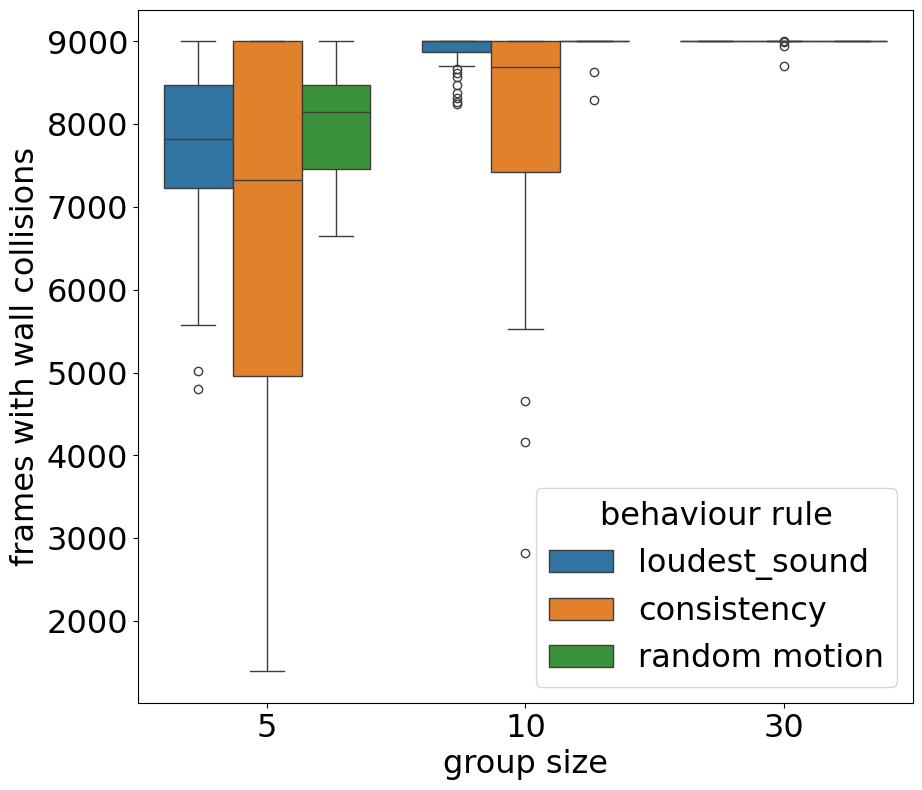

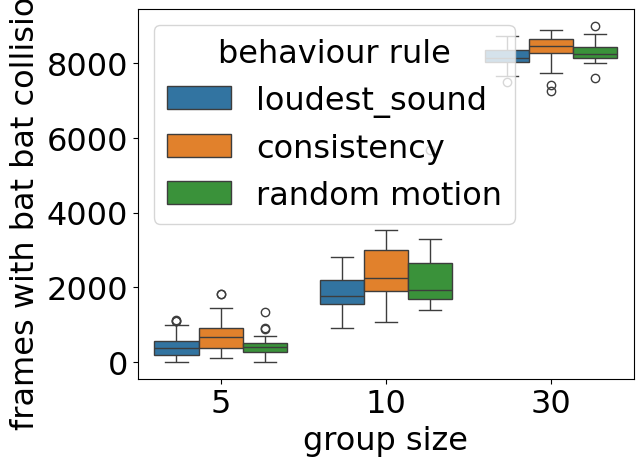

In [ ]:
# print(dict_w_values)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 9))
plt.rcParams["font.size"] = "23"
# plt.subplot(1, 3, 1)
ax = sns.boxplot(data=df_merged2, x="group size", y="frames with wall collisions", hue="behaviour rule")
plt.show()
ax = sns.boxplot(data=df_merged2, x="group size", y="frames with bat bat collisions", hue="behaviour rule")
plt.show()
# ax = sns.violinplot(data=dicts_random, x="group size", y="collision counts", hue="call rate")

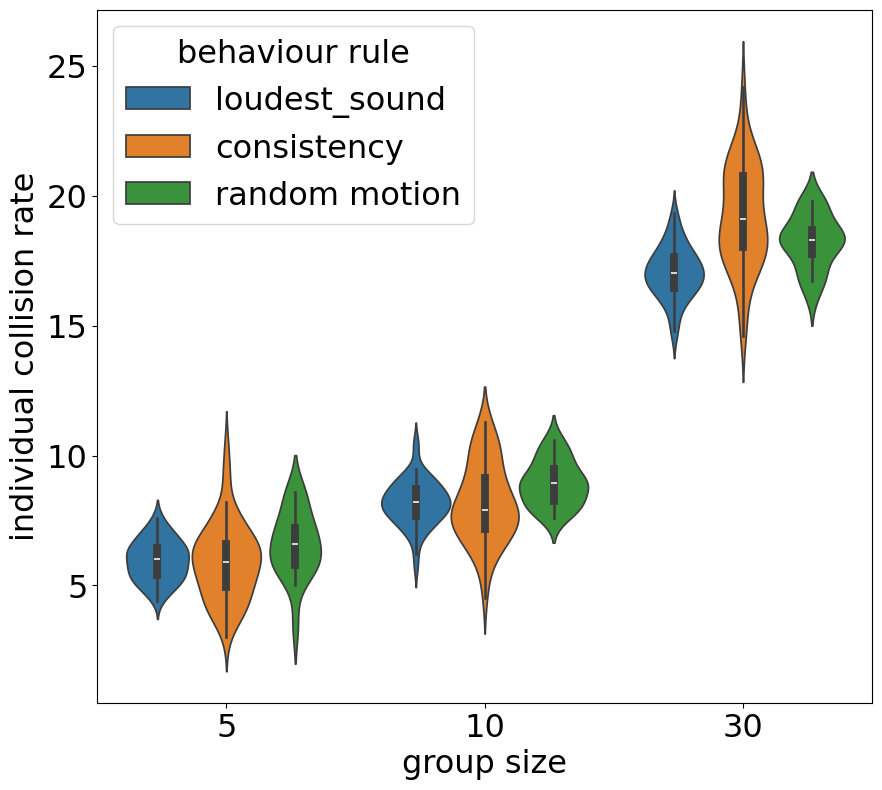

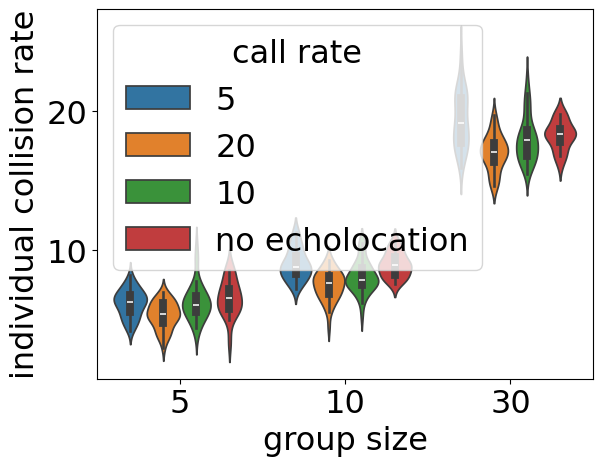

In [ ]:

plt.figure(figsize=(10, 9))
plt.rcParams["font.size"] = "23"
# plt.subplot(1, 3, 1)
ax = sns.violinplot(data=df_merged, x="group size", y="individual collision rate", hue="behaviour rule")
plt.show()
ax = sns.violinplot(data=df_merged, x="group size", y="individual collision rate", hue="call rate")
plt.show()

In [ ]:
df_merged

,collision rate,total collisions,wall collisions,bat bat collisions,group size,call rate,behaviour rule,individual collision rate,"individual collision rate, bat-bat","individual collision rate, wall"
0,3329.666667,62,43,19,10,20,loudest_sound,7.9,3.6,4.3
1,4702.000000,60,40,20,10,20,loudest_sound,8.0,4.0,4.0
2,4037.444444,57,41,16,10,20,loudest_sound,7.1,3.0,4.1
3,3571.666667,59,39,20,10,20,loudest_sound,7.9,4.0,3.9
4,3112.666667,59,40,19,10,20,loudest_sound,7.8,3.8,4.0
...,...,...,...,...,...,...,...,...,...,...
414,3445.666667,74,49,25,10,no echolocation,random motion,9.9,5.0,4.9
415,3661.444444,63,43,20,10,no echolocation,random motion,8.3,4.0,4.3
416,3688.333333,77,46,31,10,no echolocation,random motion,10.6,6.0,4.6
417,4255.222222,62,41,21,10,no echolocation,random motion,8.3,4.2,4.1


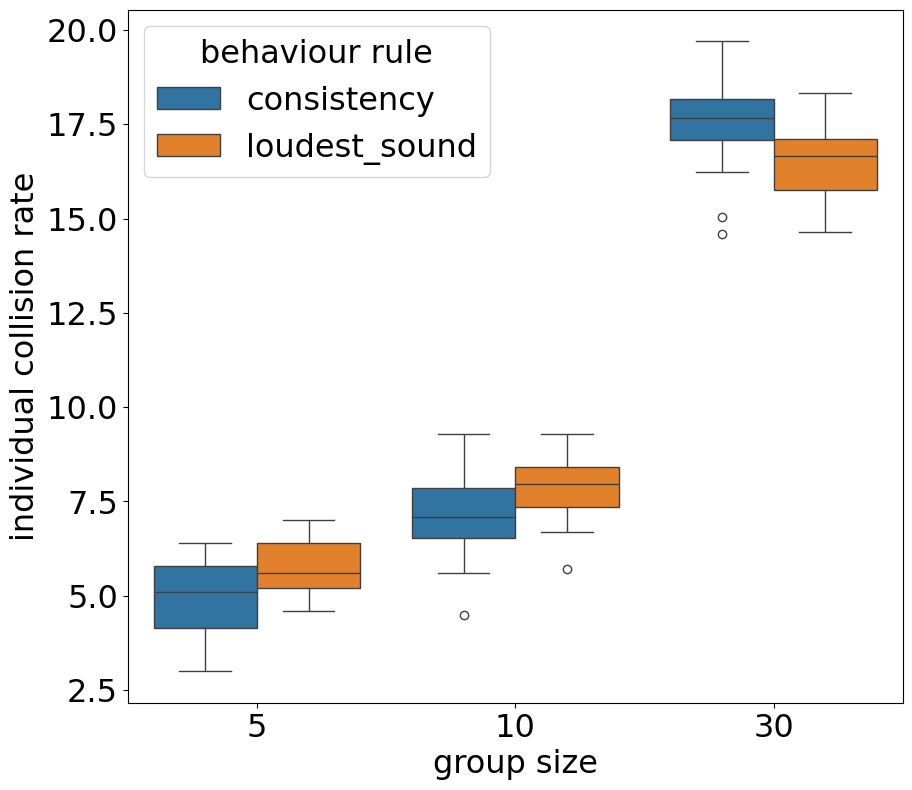

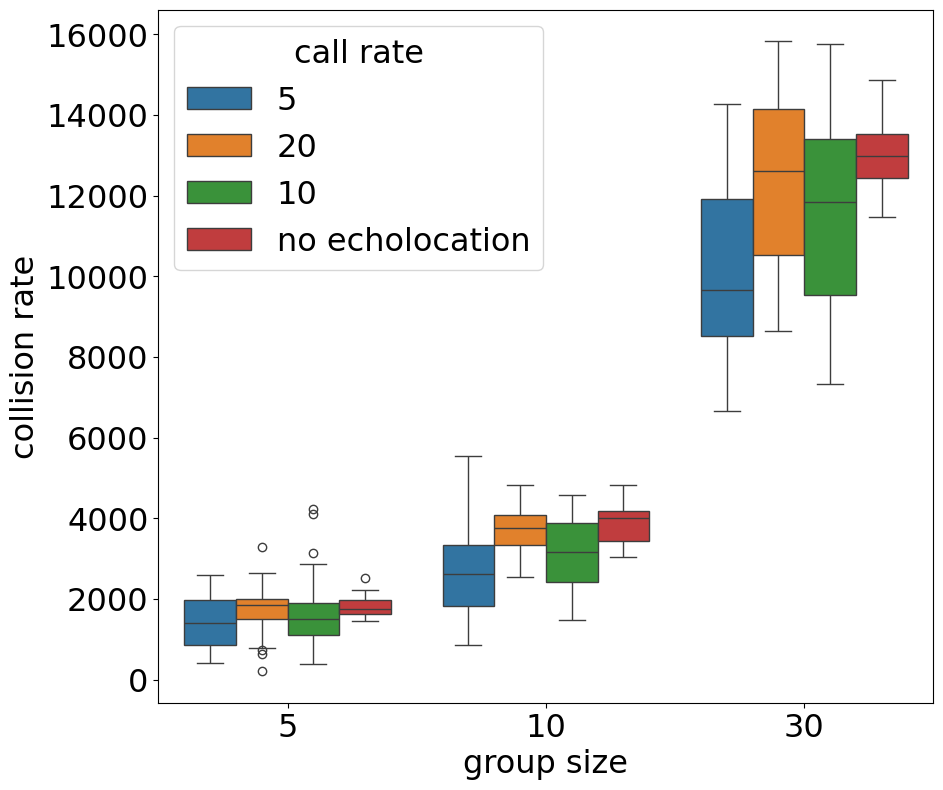

In [ ]:
# print(dict_w_values)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 9))
plt.rcParams["font.size"] = "23"
# plt.subplot(1, 3, 1)
ax = sns.boxplot(data=df_merged[df_merged["call rate"].isin(["None", 20])], x="group size", y="individual collision rate", hue="behaviour rule")#, errorbar="se", capsize=.2, estimator = np.mean)
plt.show()
plt.figure(figsize=(10, 9))
ax = sns.boxplot(data=df_merged, x="group size", y="collision rate", hue="call rate")#, errorbar="se", capsize=.2, estimator = np.mean)
plt.show()
# ax = sns.violinplot(data=dicts_random, x="group size", y="collision rate per second", hue="call rate")

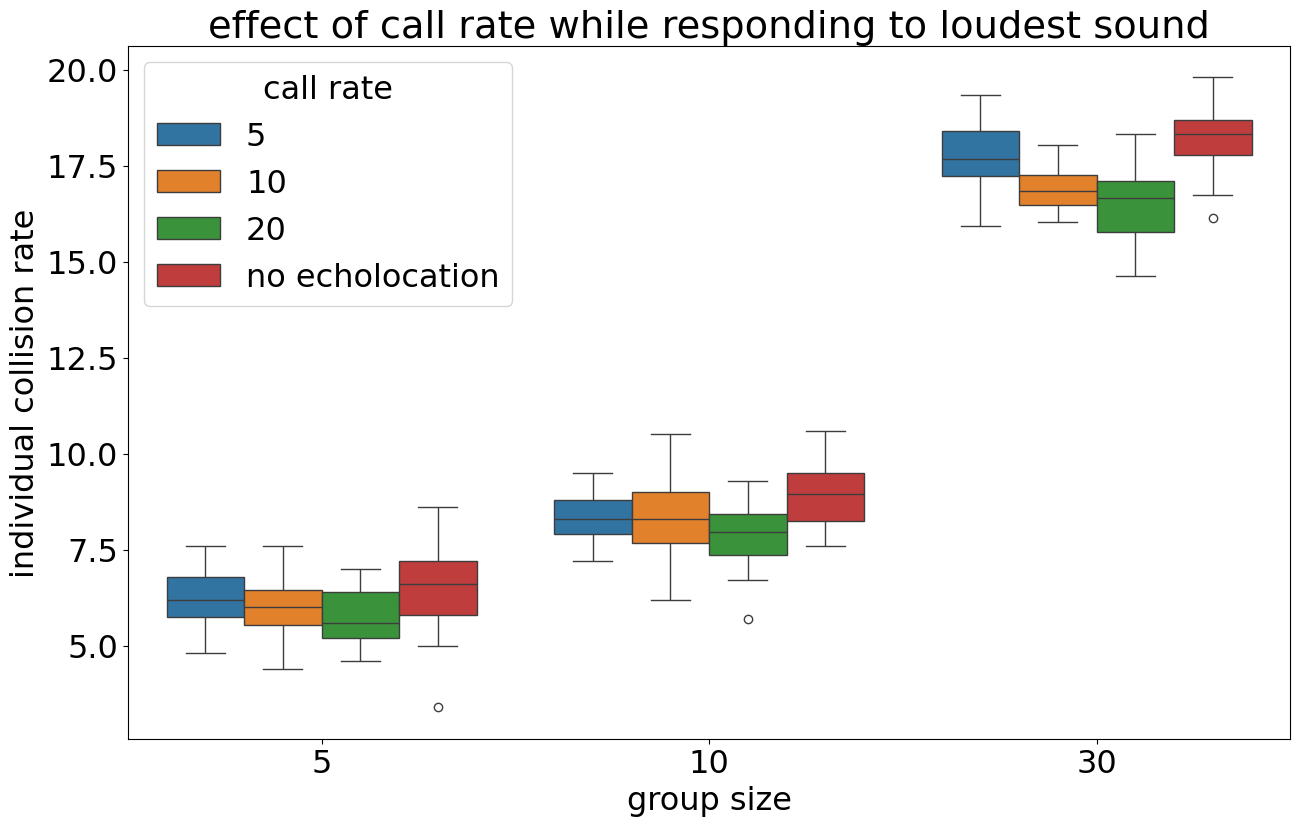

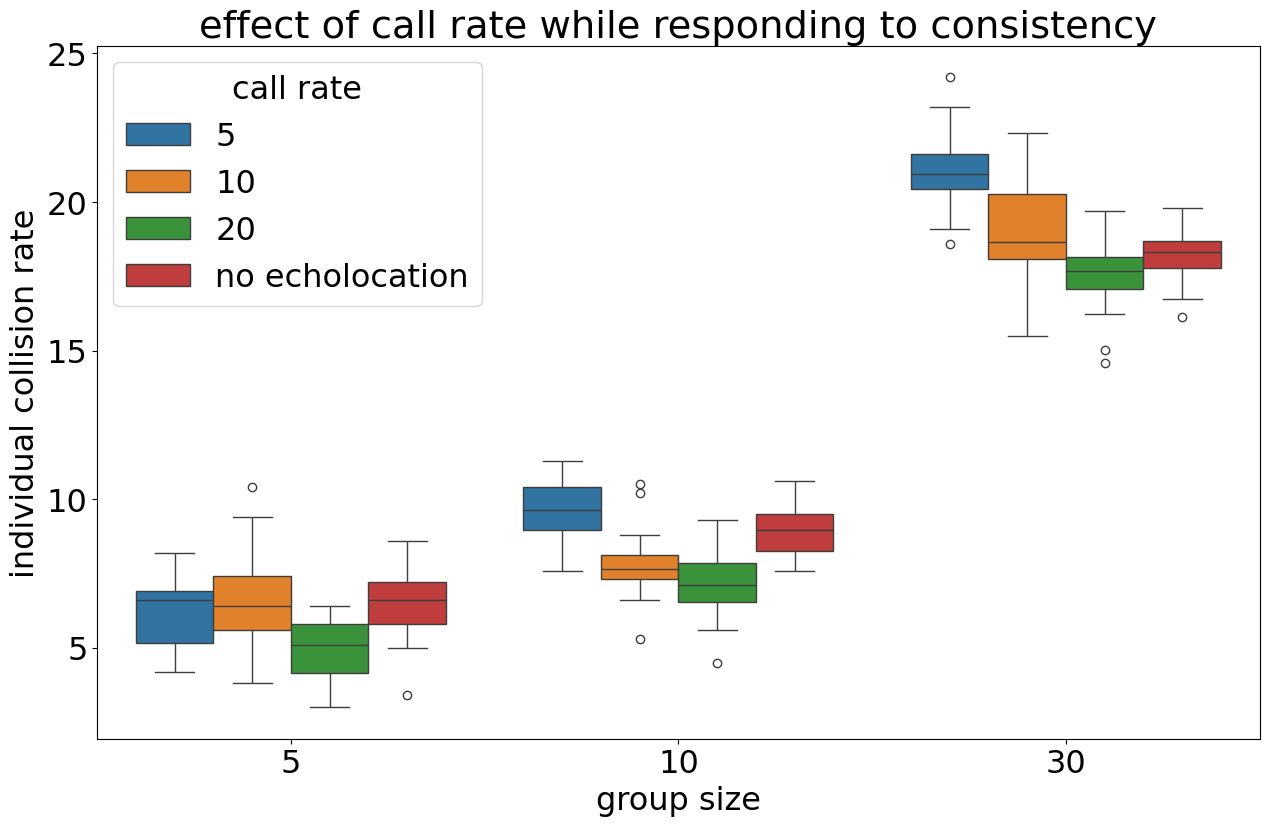

In [ ]:
# print(dict_w_values)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 9))
subset_df = df_merged[df_merged["behaviour rule"].isin(["loudest_sound", "random motion"])]
ax = sns.boxplot(data=subset_df, x="group size", y="individual collision rate", hue="call rate", hue_order=[5, 10, 20, "no echolocation"])#, errorbar="se", capsize=.2, estimator = np.mean, hue_order=[5, 10, 20, "no echolocation"])
plt.title("effect of call rate while responding to loudest sound")
plt.show()
plt.figure(figsize=(15, 9))
subset_df = df_merged[df_merged["behaviour rule"].isin(["consistency", "random motion"])]
ax = sns.boxplot(data=subset_df, x="group size", y="individual collision rate", hue="call rate", hue_order=[5, 10, 20, "no echolocation"])#, errorbar="se", capsize=.2, estimator = np.mean, hue_order=[5, 10, 20, "no echolocation"])
plt.title("effect of call rate while responding to consistency")
plt.show()
# ax = sns.viol

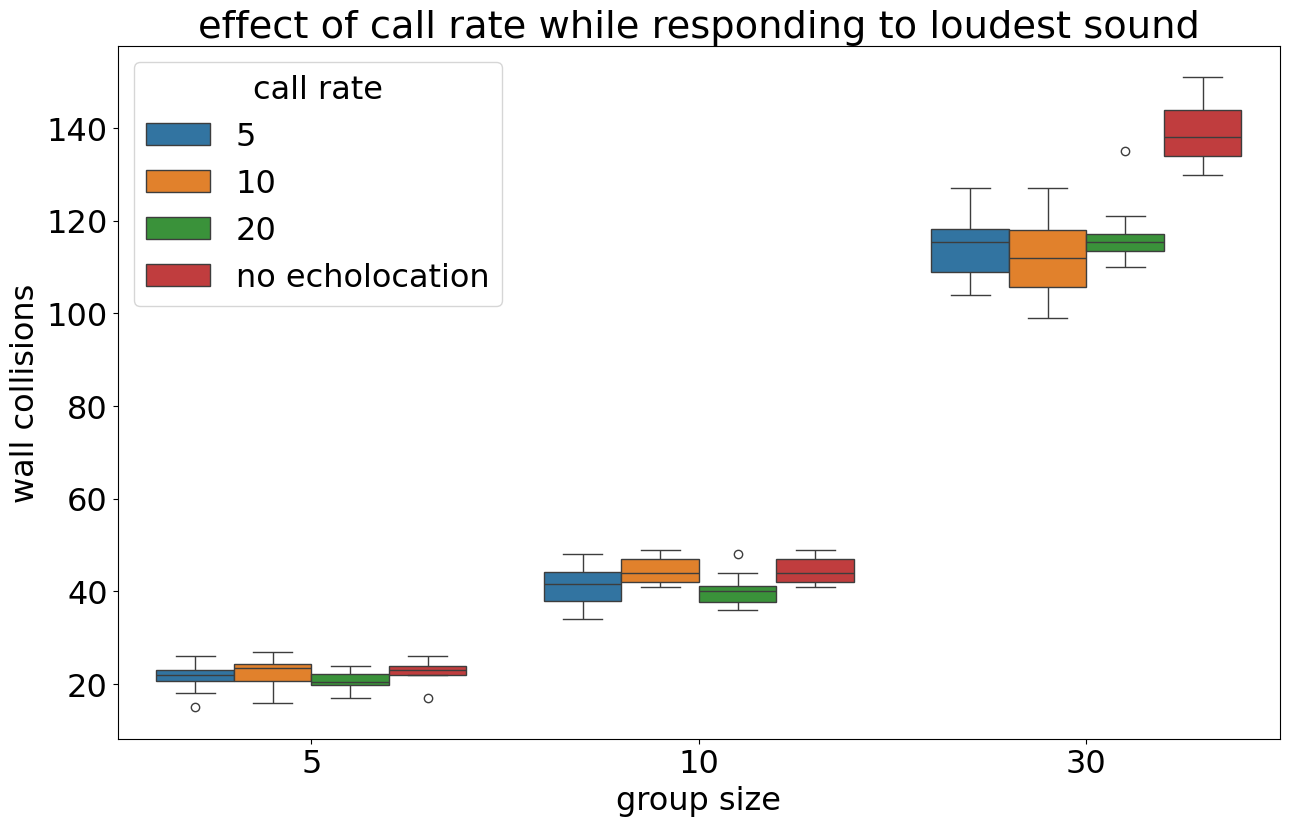

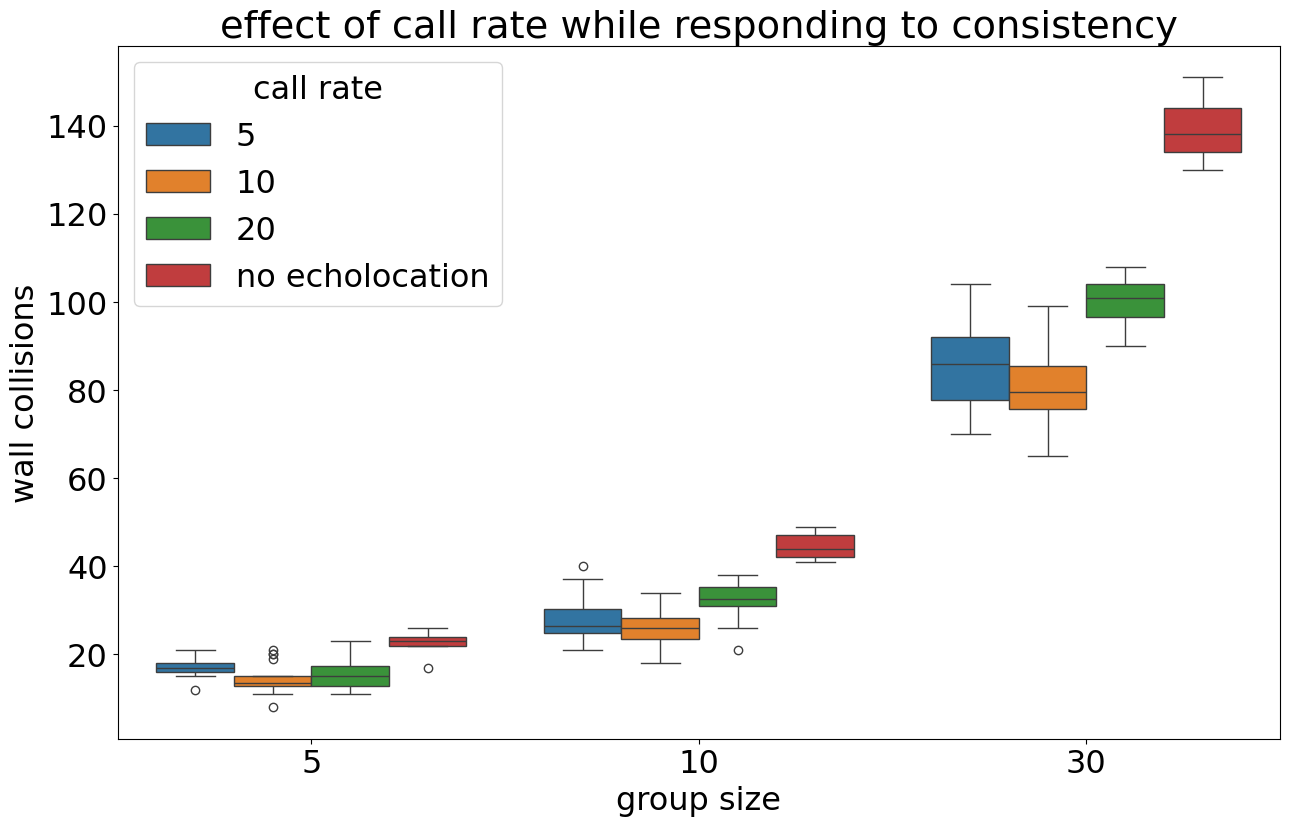

In [ ]:
plt.figure(figsize=(15, 9))
subset_df = df_merged[df_merged["behaviour rule"].isin(["loudest_sound", "random motion"])]
ax = sns.boxplot(data=subset_df, x="group size", y="wall collisions", hue="call rate", hue_order=[5, 10, 20, "no echolocation"])#, errorbar="se", capsize=.2, estimator = np.mean, hue_order=[5, 10, 20, "no echolocation"])
plt.title("effect of call rate while responding to loudest sound")
plt.show()
plt.figure(figsize=(15, 9))
subset_df = df_merged[df_merged["behaviour rule"].isin(["consistency", "random motion"])]
ax = sns.boxplot(data=subset_df, x="group size", y="wall collisions", hue="call rate", hue_order=[5, 10, 20, "no echolocation"])#, errorbar="se", capsize=.2, estimator = np.mean, hue_order=[5, 10, 20, "no echolocation"])
plt.title("effect of call rate while responding to consistency")
plt.show()

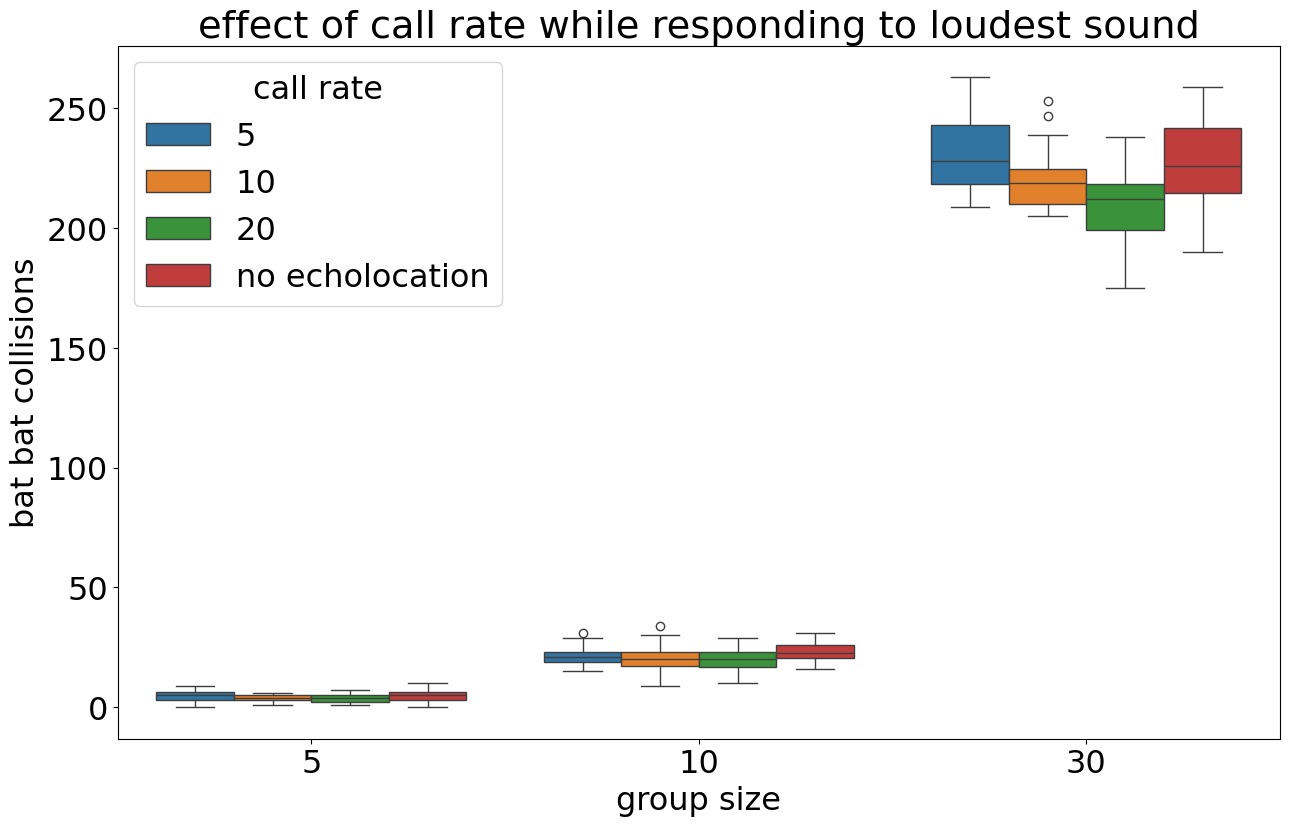

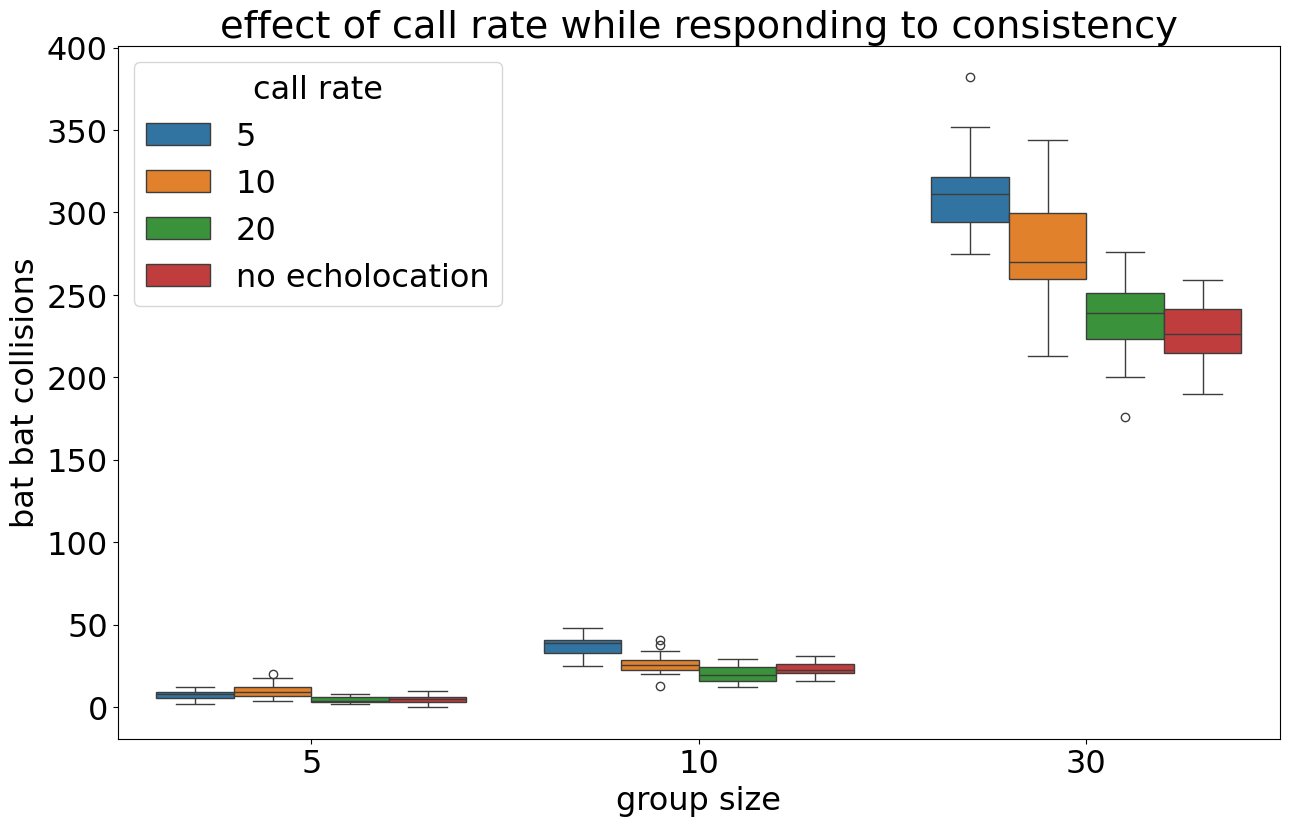

In [ ]:
plt.figure(figsize=(15, 9))
subset_df = df_merged[df_merged["behaviour rule"].isin(["loudest_sound", "random motion"])]
ax = sns.boxplot(data=subset_df, x="group size", y="bat bat collisions", hue="call rate", hue_order=[5, 10, 20, "no echolocation"])#, errorbar="se", capsize=.2, estimator = np.mean, hue_order=[5, 10, 20, "no echolocation"])
plt.title("effect of call rate while responding to loudest sound")
plt.show()
plt.figure(figsize=(15, 9))
subset_df = df_merged[df_merged["behaviour rule"].isin(["consistency", "random motion"])]
ax = sns.boxplot(data=subset_df, x="group size", y="bat bat collisions", hue="call rate", hue_order=[5, 10, 20, "no echolocation"])#, errorbar="se", capsize=.2, estimator = np.mean, hue_order=[5, 10, 20, "no echolocation"])
plt.title("effect of call rate while responding to consistency")
plt.show()

In [ ]:
np.savez("nvg_condensed_data_1.npz",dicts)

In [ ]:
df = pd.DataFrame.from_dict(dicts)
df

,collision rate per second,collision counts,group size,call rate,behaviour rule
0,2.739333,57,10,20,loudest_sound
1,4.110667,55,10,20,loudest_sound
2,3.358778,48,10,20,loudest_sound
3,3.012667,54,10,20,loudest_sound
4,2.584889,50,10,20,loudest_sound
...,...,...,...,...,...
354,1.704778,19,5,10,consistency
355,3.767556,28,5,10,consistency
356,1.739222,26,5,10,consistency
357,0.859333,21,5,10,consistency


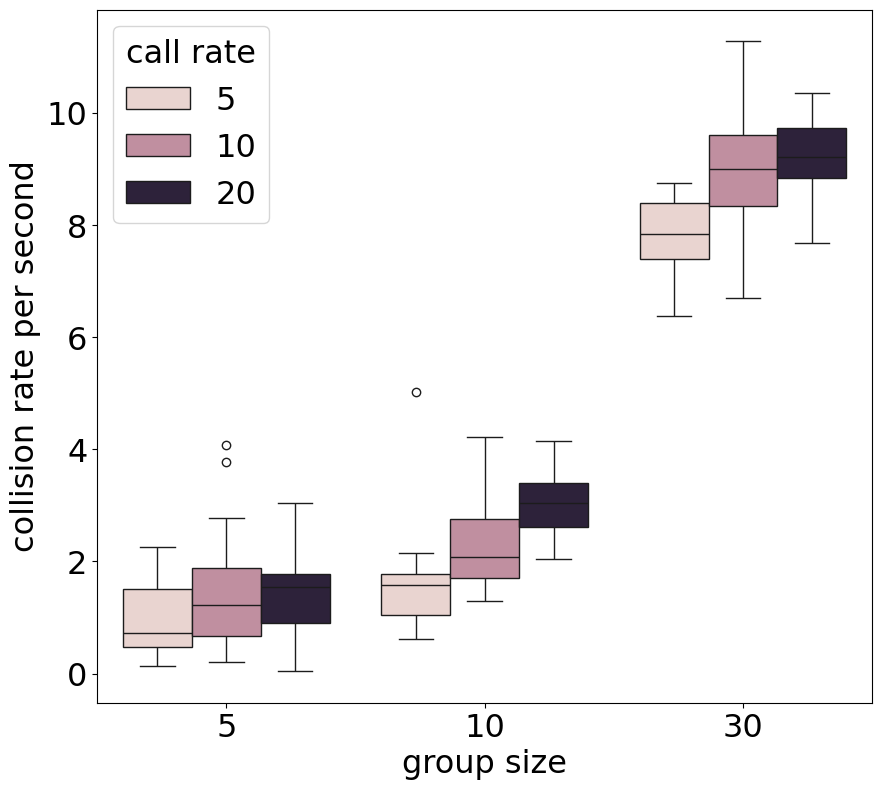

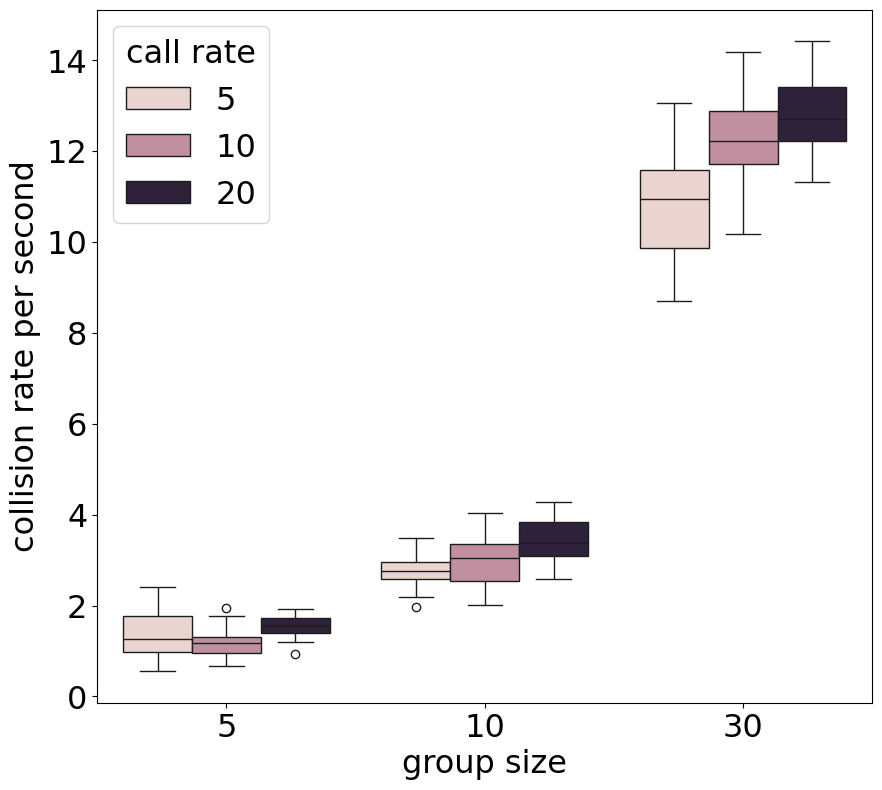

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 9))
plt.rcParams["font.size"] = "23"
# plt.subplot(1, 3, 1)
df_consitency = df[df["behaviour rule"] == "consistency"]
ax = sns.boxplot(data=df_consitency, x="group size", y="collision rate per second", hue="call rate")
# plt.show()
plt.figure(figsize=(10, 9))
plt.rcParams["font.size"] = "23"
# plt.subplot(1, 3, 1)
df_consitency = df[df["behaviour rule"] == "loudest_sound"]
ax = sns.boxplot(data=df_consitency, x="group size", y="collision rate per second", hue="call rate")
# ax = sns.violinplot(data=dicts, x="group size", y="collision rate per second", hue="call rate")

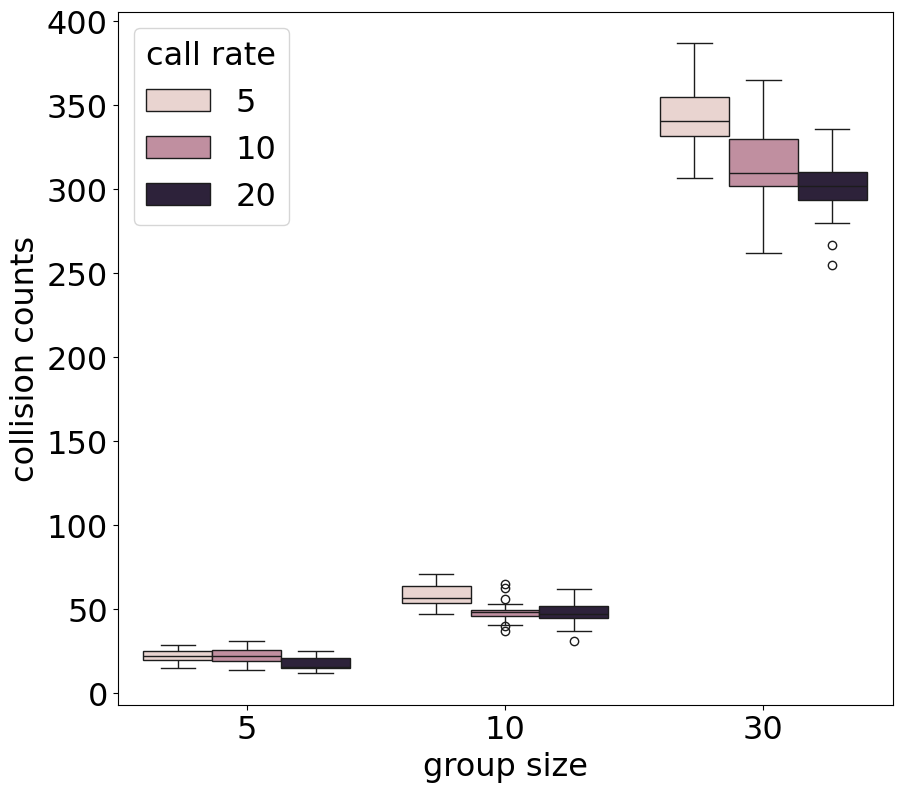

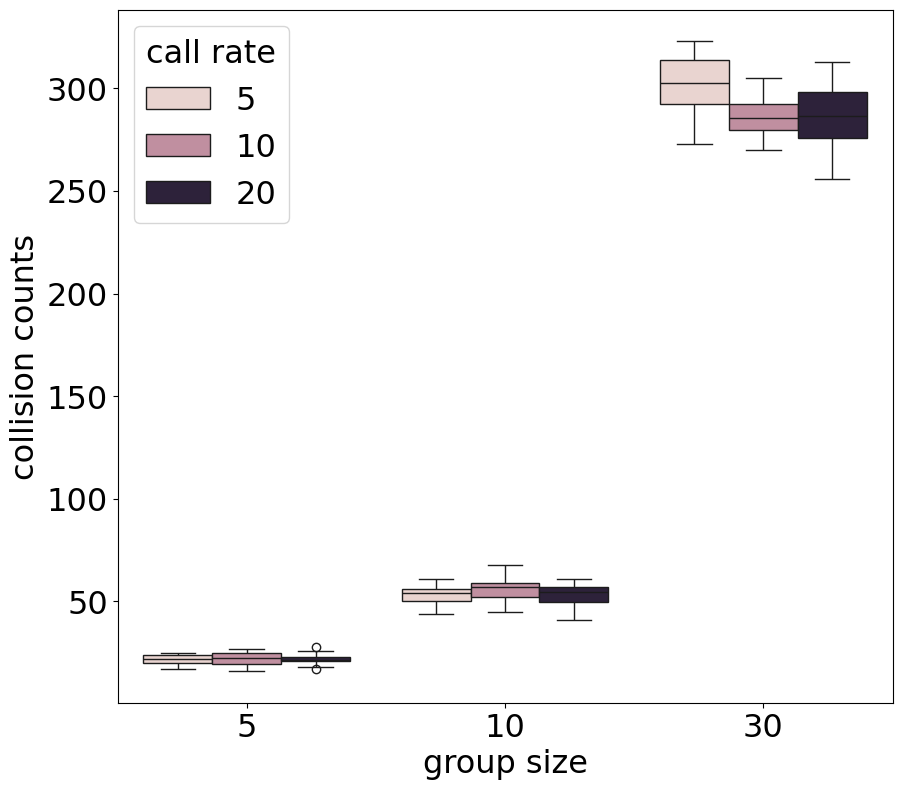

In [ ]:
plt.figure(figsize=(10, 9))
plt.rcParams["font.size"] = "23"
# plt.subplot(1, 3, 1)
df_consitency = df[df["behaviour rule"] == "consistency"]
ax = sns.boxplot(data=df_consitency, x="group size", y="collision counts", hue="call rate")
plt.show()
plt.figure(figsize=(10, 9))
plt.rcParams["font.size"] = "23"
# plt.subplot(1, 3, 1)
df_consitency = df[df["behaviour rule"] == "loudest_sound"]
ax = sns.boxplot(data=df_consitency, x="group size", y="collision counts", hue="call rate")

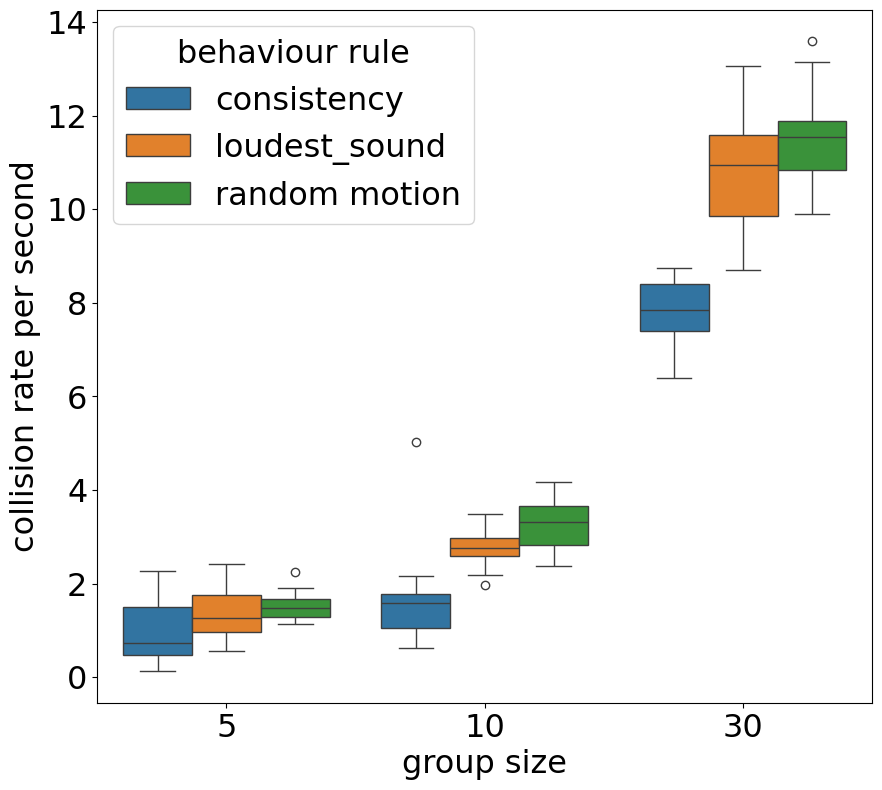

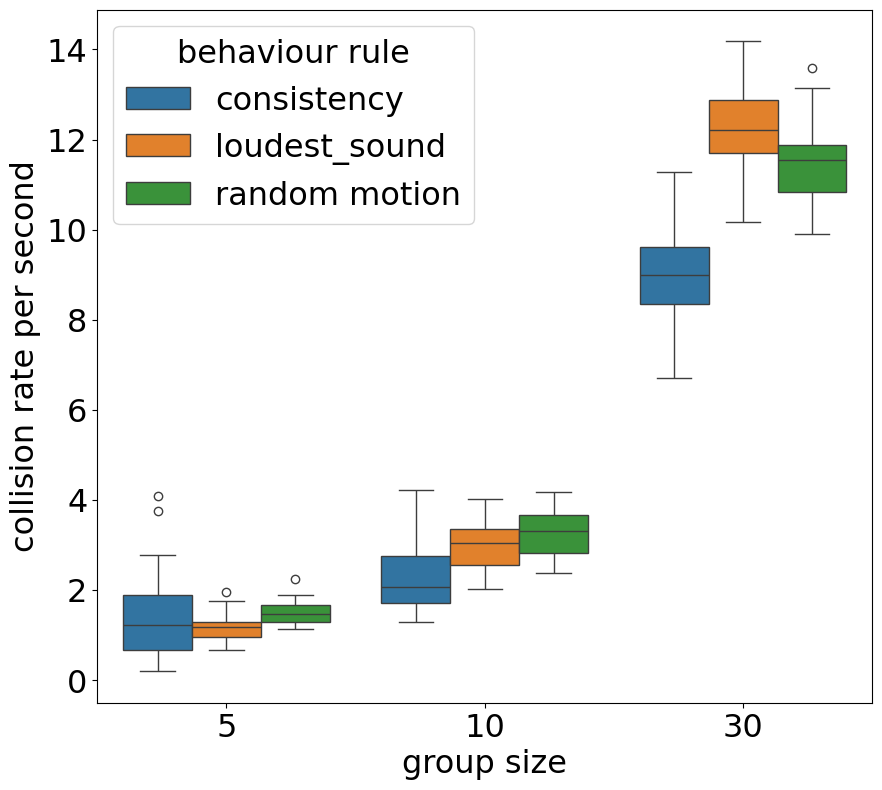

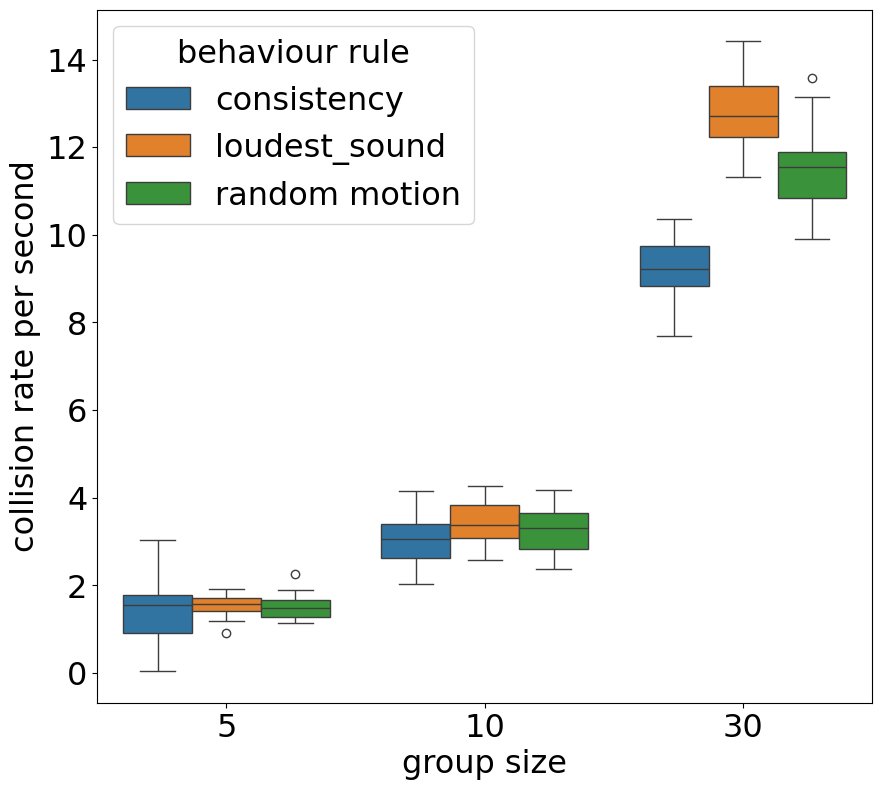

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 9))
plt.rcParams["font.size"] = "23"
# plt.subplot(1, 3, 1)
df_consitency = df_merged[df_merged["call rate"].isin([5,"None"])]
ax = sns.boxplot(data=df_consitency, x="group size", y="collision rate per second", hue="behaviour rule", hue_order=["consistency", "loudest_sound", "random motion"])

plt.figure(figsize=(10, 9))
plt.rcParams["font.size"] = "23"
# plt.subplot(1, 3, 1)
df_consitency = df_merged[df_merged["call rate"].isin([10,"None"])]
ax = sns.boxplot(data=df_consitency, x="group size", y="collision rate per second", hue="behaviour rule", hue_order=["consistency", "loudest_sound", "random motion"])

plt.figure(figsize=(10, 9))
plt.rcParams["font.size"] = "23"
# plt.subplot(1, 3, 1)
df_consitency = df_merged[df_merged["call rate"].isin([20,"None"])]
ax = sns.boxplot(data=df_consitency, x="group size", y="collision rate per second", hue="behaviour rule", hue_order=["consistency", "loudest_sound", "random motion"])

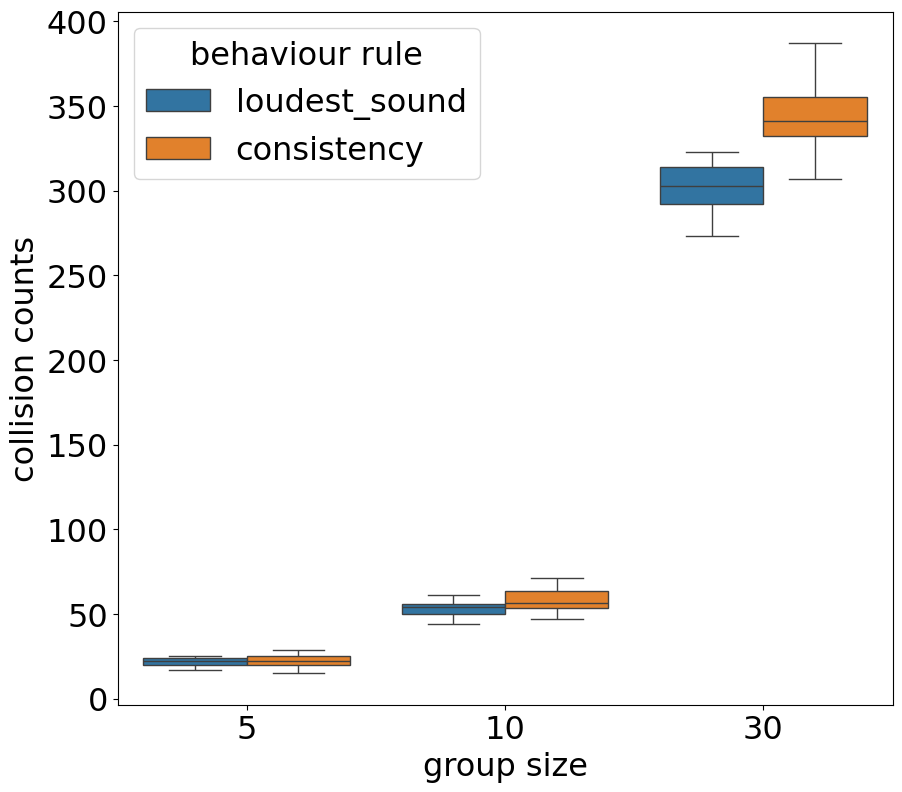

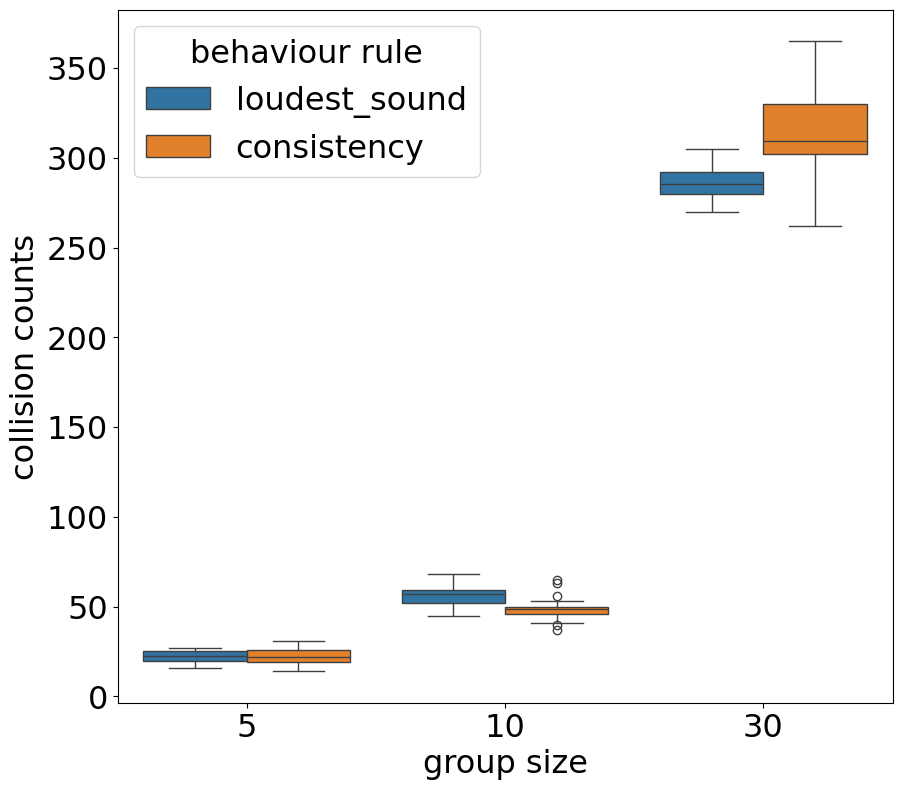

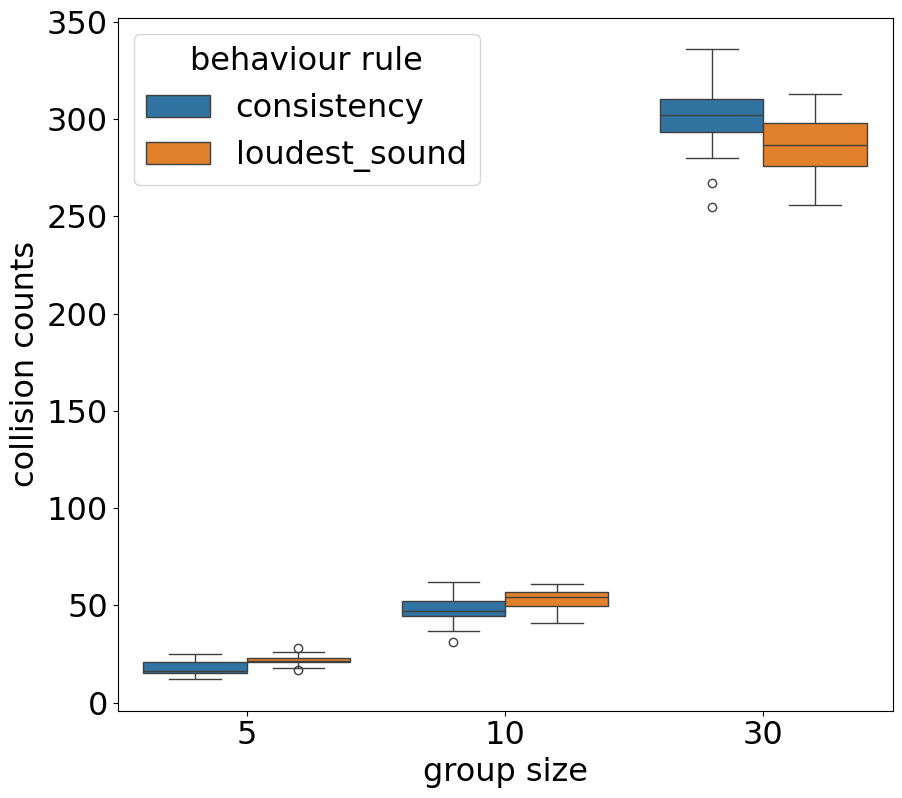

In [ ]:
plt.figure(figsize=(10, 9))
plt.rcParams["font.size"] = "23"
# plt.subplot(1, 3, 1)
df_consitency = df[df["call rate"] == 5]
ax = sns.boxplot(data=df_consitency, x="group size", y="collision counts", hue="behaviour rule")

plt.figure(figsize=(10, 9))
plt.rcParams["font.size"] = "23"
# plt.subplot(1, 3, 1)
df_consitency = df[df["call rate"] == 10]
ax = sns.boxplot(data=df_consitency, x="group size", y="collision counts", hue="behaviour rule")

plt.figure(figsize=(10, 9))
plt.rcParams["font.size"] = "23"
# plt.subplot(1, 3, 1)
df_consitency = df[df["call rate"] == 20]
ax = sns.boxplot(data=df_consitency, x="group size", y="collision counts", hue="behaviour rule")

In [ ]:
x = np.load("nvg_condensed_data.npz", allow_pickle=True)
x["arr_0"]

array({'collision rate': [np.float64(2.6478), np.float64(3.9698), np.float64(3.2849), np.float64(2.8597), np.float64(2.656), np.float64(2.9271), np.float64(2.6595), np.float64(3.2241), np.float64(4.0752), np.float64(3.3753), np.float64(3.4429), np.float64(4.0484), np.float64(3.7657), np.float64(4.2009), np.float64(3.7685), np.float64(3.61), np.float64(2.7603), np.float64(2.9623), np.float64(3.5533), np.float64(3.2553), np.float64(8.1349), np.float64(8.7195), np.float64(8.6895), np.float64(7.9615), np.float64(8.3737), np.float64(6.7026), np.float64(8.0392), np.float64(7.5503), np.float64(8.5634), np.float64(6.7602), np.float64(8.4653), np.float64(8.9761), np.float64(7.3103), np.float64(8.1309), np.float64(8.1444), np.float64(7.459), np.float64(7.7815), np.float64(8.9497), np.float64(8.5351), np.float64(7.5715), np.float64(12.5867), np.float64(9.9416), np.float64(8.8605), np.float64(10.3183), np.float64(9.8594), np.float64(11.192), np.float64(11.5707), np.float64(9.1042), np.float64(10.5

In [ ]:
import pickle 
df  = pd.read_pickle("nvg_final_data.pkl")
df["collision rate"]*9

0      29967.0
1      42318.0
2      36337.0
3      32145.0
4      28014.0
        ...   
414    31011.0
415    32953.0
416    33195.0
417    38297.0
418    37578.0
Name: collision rate, Length: 419, dtype: float64

In [ ]:
mean_random_collision_rate = np.mean((df[df["behaviour rule"] == "random motion"]["collision rate"]))
normalized_collision_rates = np.array(df["collision rate"]/mean_random_collision_rate)
df["normalized collision rates"] = normalized_collision_rates
(df[df["behaviour rule"] == "random motion"]["collision rate"])

359     2529.777778
360     2040.444444
361     1449.111111
362     1635.666667
363     1817.333333
364     1674.777778
365     1666.888889
366     1752.555556
367     2079.777778
368     1836.888889
369     1523.222222
370     1752.222222
371     1966.555556
372     1562.111111
373     2133.555556
374     1872.000000
375     1687.222222
376     2218.333333
377     1583.000000
378     1498.555556
379    14357.000000
380    12875.111111
381    12771.000000
382    13091.666667
383    13363.444444
384    11535.111111
385    11737.888889
386    11951.111111
387    11465.000000
388    13756.888889
389    12811.444444
390    12847.666667
391    13165.777778
392    14878.111111
393    13277.555556
394    11790.444444
395    13656.666667
396    13732.666667
397    12599.888889
398    13481.555556
399     3942.111111
400     3858.555556
401     3063.666667
402     4823.777778
403     3296.888889
404     4059.222222
405     4078.111111
406     4472.222222
407     4137.111111
408     3176.555556


In [ ]:
group_sizes = [5,10,30]
mean_random_collision_rates = []
for group_size in group_sizes:
    df_subset = df[df["group size"] == group_size]
    mean_random_collision_rate = np.mean((df_subset[df_subset["behaviour rule"] == "random motion"]["collision rate"]))
    print(mean_random_collision_rate)
    mean_random_collision_rates.append(mean_random_collision_rate)
    
    
array_store_normalized_rates = []
for i in range(len(df["collision rate"])):
    for j,group_size in enumerate(group_sizes):
        if df["group size"][i] == group_size:
            normalized_rate = df["collision rate"][i]/mean_random_collision_rates[j]
            array_store_normalized_rates.append(normalized_rate)
            
df["normalized collision rates"] = array_store_normalized_rates

1814.0
3869.683333333333
12957.3


In [ ]:
df[df["behaviour rule"] == "random motion"]["normalized collision rates"]

359    0.407132
360    0.328380
361    0.233214
362    0.263237
363    0.292474
364    0.269532
365    0.268262
366    0.282049
367    0.334711
368    0.295621
369    0.245141
370    0.281995
371    0.316489
372    0.251399
373    0.343365
374    0.301272
375    0.271534
376    0.357009
377    0.254761
378    0.241171
379    2.310554
380    2.072065
381    2.055310
382    2.106917
383    2.150656
384    1.856411
385    1.889046
386    1.923361
387    1.845128
388    2.213975
389    2.061819
390    2.067648
391    2.118844
392    2.394419
393    2.136833
394    1.897504
395    2.197845
396    2.210077
397    2.027772
398    2.169664
399    0.634426
400    0.620979
401    0.493053
402    0.776318
403    0.530587
404    0.653274
405    0.656314
406    0.719740
407    0.665809
408    0.511221
409    0.695135
410    0.550293
411    0.491033
412    0.710030
413    0.653041
414    0.554531
415    0.589257
416    0.593585
417    0.684817
418    0.671960
Name: normalized collision rates, dtype:

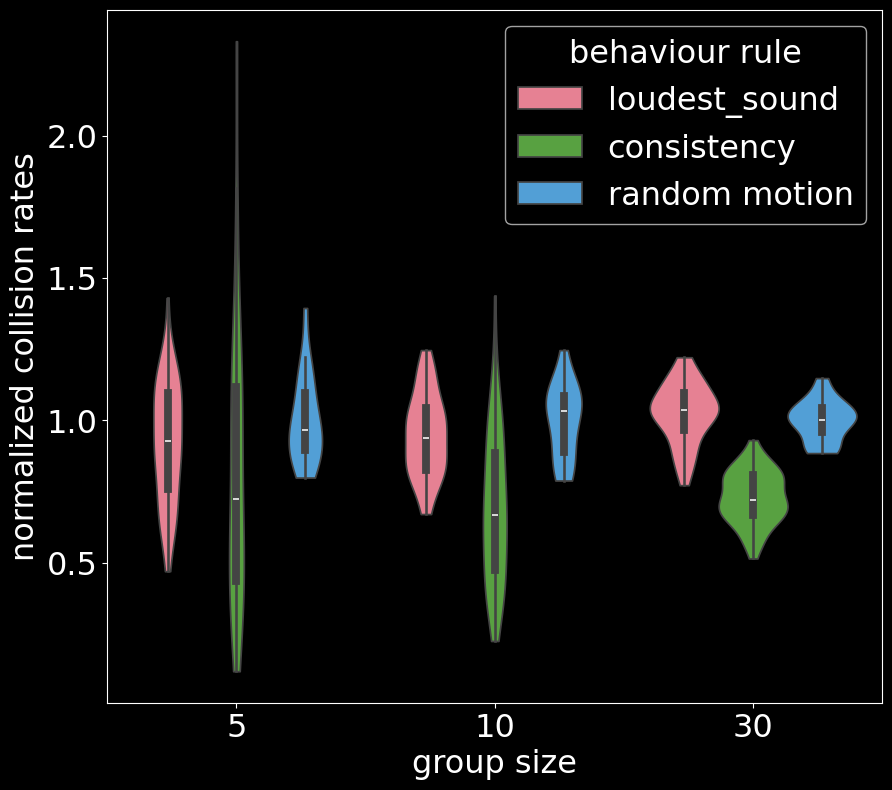

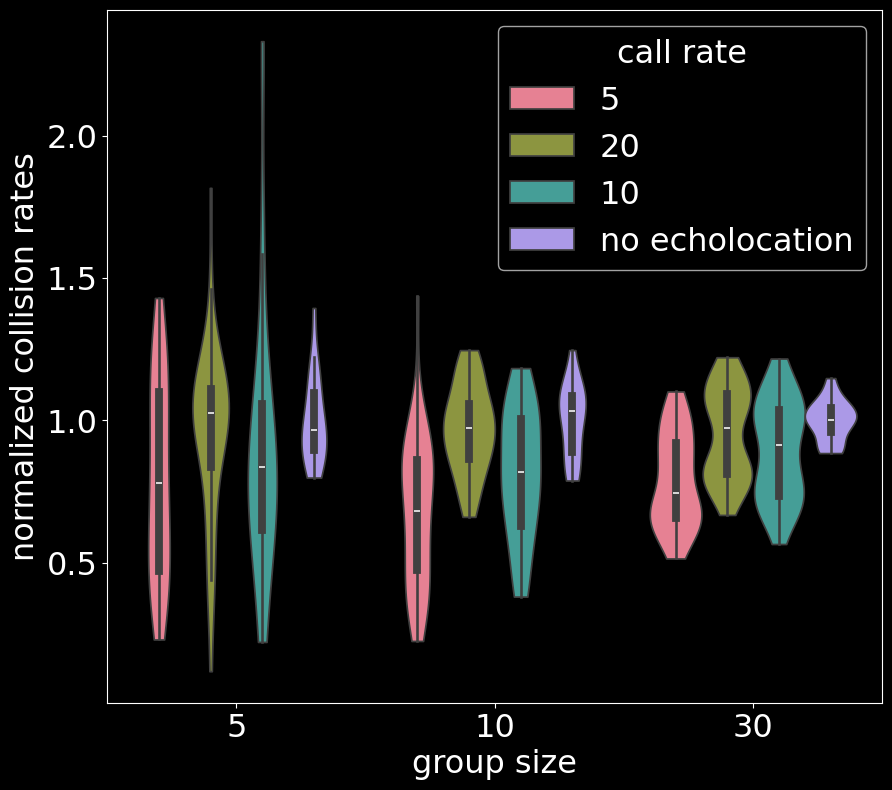

In [ ]:

plt.figure(figsize=(10, 9))
plt.rcParams["font.size"] = "23"
# plt.subplot(1, 3, 1)
ax = sns.violinplot(data=df, x="group size", y="normalized collision rates", hue="behaviour rule", cut=0, palette="husl")#, errorbar="se", capsize=.2, estimator = np.mean)
plt.show()
plt.figure(figsize=(10, 9))
ax = sns.violinplot(data=df, x="group size", y="normalized collision rates", hue="call rate", cut=0, palette="husl")#, errorbar="se", capsize=.2, estimator = np.mean)
plt.show()
# ax = sns.violinplot(data=dicts_random, x="group size", y="collision rate per second", hue="call rate")

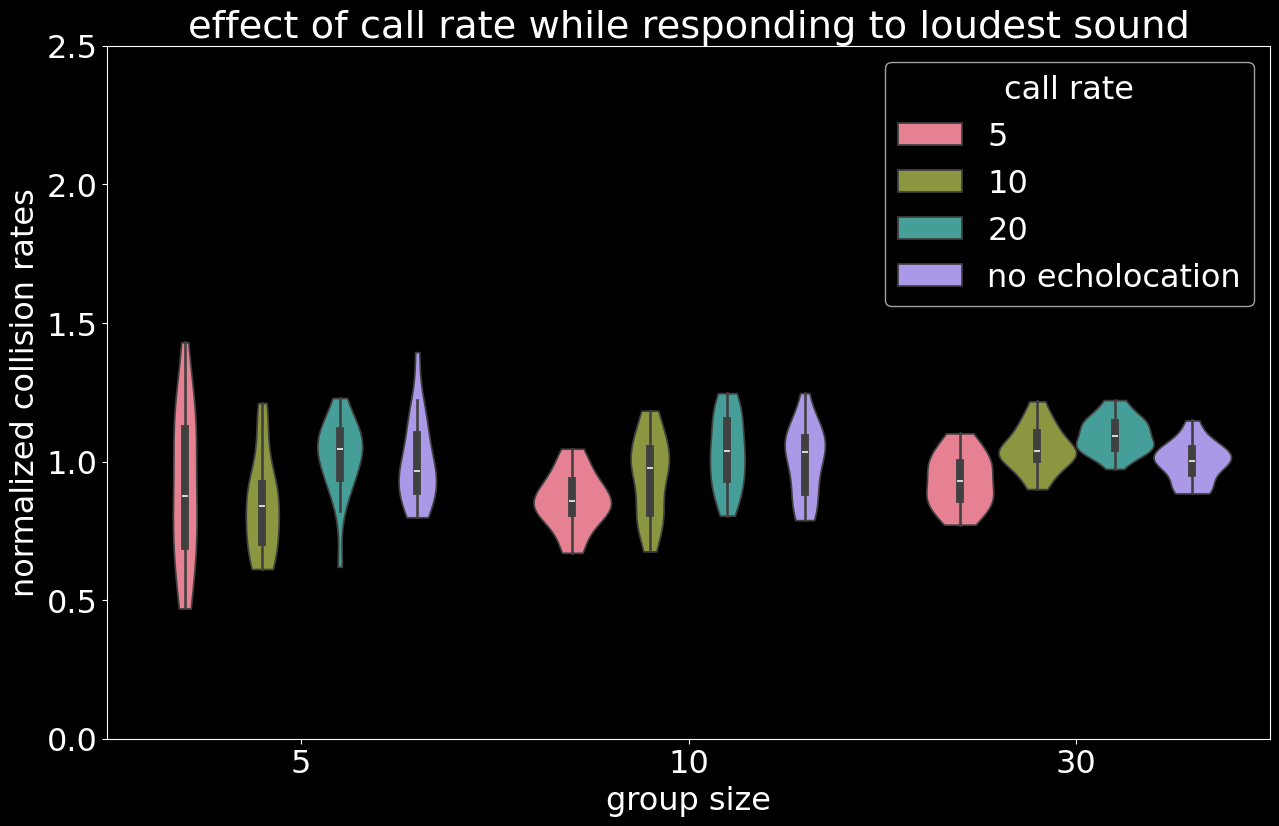

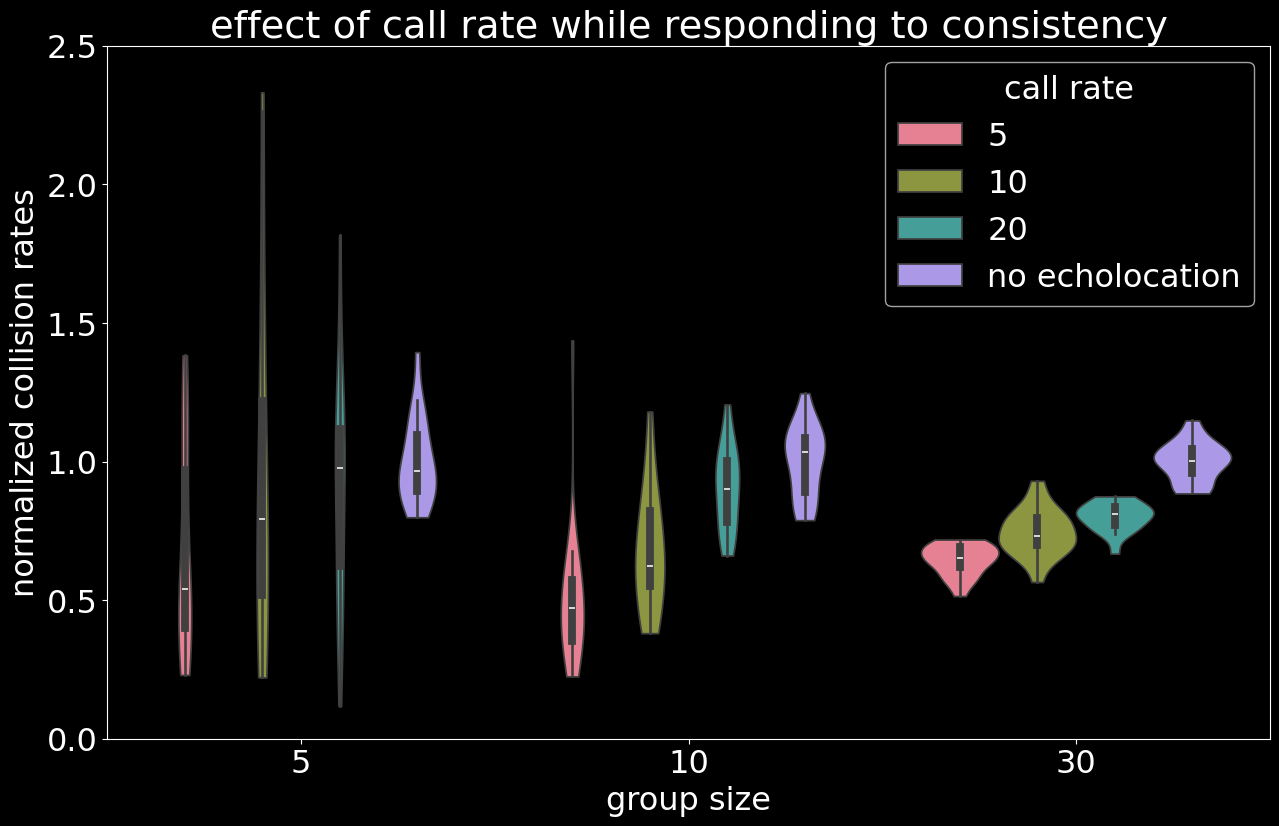

In [ ]:

plt.style.use('dark_background')
sns.color_palette("husl", 8)

plt.figure(figsize=(15, 9))
subset_df = df[df["behaviour rule"].isin(["loudest_sound", "random motion"])]
ax = sns.violinplot(data=subset_df, x="group size", y="normalized collision rates", hue="call rate", hue_order=[5, 10, 20, "no echolocation"], cut=0, palette="husl")#, errorbar="se", capsize=.2, estimator = np.mean, hue_order=[5, 10, 20, "no echolocation"])
plt.title("effect of call rate while responding to loudest sound")
plt.ylim(0,2.5)
plt.show()
plt.figure(figsize=(15, 9))
subset_df = df[df["behaviour rule"].isin(["consistency", "random motion"])]
ax = sns.violinplot(data=subset_df, x="group size", y="normalized collision rates", hue="call rate", hue_order=[5, 10, 20, "no echolocation"], cut=0, palette="husl")#, errorbar="se", capsize=.2, estimator = np.mean, hue_order=[5, 10, 20, "no echolocation"])
plt.title("effect of call rate while responding to consistency")
plt.ylim(0,2.5)
plt.show()
# ax = sns.viol